# Bicycle Road Smoothness Classifier - Super-Notbook 

- **Academic Year**: 2026 - 2027, quarter 1, 4th of October
- **Course**: 5ARE0
- **Group**: 19
- **Students**: Richard Kroesen (2238594), name (student-id)
 

---
*Copied from `notebooks/plot_datasets.ipynb`*

# 0) NOTEBOOK ENTRY & SETUP

In [163]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

DATA_DIR = Path("./data")
SENSORS = ["Accelerometer", "TotalAcceleration", "Gravity", "Gyroscope"] 

FS = 100
TRIM_S = 5  # seconds removed from start and end

FIG_DIR = Path("./figures")          # exported folder
FIG_DIR.mkdir(exist_ok=True)

# 1) PRE PROCESSING STAGE
## 1.1 Data set loading

In [164]:
def load_dataset(folder: Path) -> dict:
    """Load one recording folder: metadata, sensor CSVs and the location photo."""
    meta = pd.read_csv(folder / "Metadata.csv").iloc[0].to_dict()

    sensors = {}
    for name in SENSORS:
        csv = folder / f"{name}.csv"
        if csv.exists():
            df = pd.read_csv(csv)
            df["t"] = df["seconds_elapsed"]
            sensors[name] = df

    photos = sorted(list(folder.glob("*.jpg")) + list(folder.glob("*.jpeg")) + list(folder.glob("*.png")))
    photo = None
    if photos:
        photo = ImageOps.exif_transpose(Image.open(photos[0]))
        photo.thumbnail((1200, 1200))   #to keep notebook light

    start = pd.to_datetime(meta["recording epoch time"], unit="ms", utc=True).tz_convert(meta["recording timezone"])
    return {
        "name": folder.name,
        "folder": folder,
        "meta": meta,
        "start": start,
        "sensors": sensors,
        "photo": photo,
        "photo_name": photos[0].name if photos else None,
    }

datasets = [load_dataset(d) for d in sorted(DATA_DIR.iterdir()) if d.is_dir()]
print(f"Loaded {len(datasets)} datasets:", [d["name"] for d in datasets])

Loaded 26 datasets: ['P01_B01', 'P01_B02', 'P01_B03', 'P01_B04', 'P01_B05', 'P01_B06', 'P01_S01', 'P01_S02', 'P01_S03', 'P01_S04', 'P02_B01', 'P02_B02', 'P02_B03', 'P02_B04', 'P02_S01', 'P02_S02', 'P02_S03', 'P02_S04', 'P03_B01', 'P03_B02', 'P03_B03', 'P03_B04', 'P03_S01', 'P03_S02', 'P03_S03', 'P03_S04']


## 1.2 Data Inventory: 

Each row row represents each measurement.

In [165]:
LABELS = {"B": "bumpy", "S": "smooth"}

def list_recordings(data_dir: Path) -> pd.DataFrame:
    """One row per recording folder named Pxx_Byy / Pxx_Syy: id, participant, label, path, metadata."""
    rows = []
    for rec in sorted(data_dir.iterdir()):                # data/P01_B03
        if not (rec.is_dir() and (rec / "Metadata.csv").exists()):
            continue
        participant, ride = rec.name.split("_")
        meta = pd.read_csv(rec / "Metadata.csv").iloc[0]
        rows.append({
            "recording_id": rec.name,
            "participant": participant,
            "label": LABELS[ride[0]],
            "path": rec,
            "device": meta["device name"],
            "start_time": pd.to_datetime(meta["recording epoch time"], unit="ms", utc=True)
                            .tz_convert(meta["recording timezone"]),
        })
    return pd.DataFrame(rows)


recordings = list_recordings(DATA_DIR)
# print(f"{len(recordings)} recordings")
# print(recordings.groupby(["participant", "label"]).size())
recordings

,recording_id,participant,label,path,device,start_time
0,P01_B01,P01,bumpy,data\P01_B01,SM-G780G,2026-09-22 19:08:25.248000+02:00
1,P01_B02,P01,bumpy,data\P01_B02,SM-G780G,2026-09-22 19:10:13.562000+02:00
2,P01_B03,P01,bumpy,data\P01_B03,SM-G780G,2026-09-22 19:18:12.036000+02:00
3,P01_B04,P01,bumpy,data\P01_B04,SM-G780G,2026-09-22 19:13:04.689000+02:00
4,P01_B05,P01,bumpy,data\P01_B05,SM-G780G,2026-09-22 19:05:49.591000+02:00
5,P01_B06,P01,bumpy,data\P01_B06,SM-G780G,2026-09-22 19:04:51.242000+02:00
6,P01_S01,P01,smooth,data\P01_S01,SM-G780G,2026-09-22 19:16:26.646000+02:00
7,P01_S02,P01,smooth,data\P01_S02,SM-G780G,2026-09-22 19:15:02.242000+02:00
8,P01_S03,P01,smooth,data\P01_S03,SM-G780G,2026-09-22 19:07:06.701000+02:00
9,P01_S04,P01,smooth,data\P01_S04,SM-G780G,2026-09-22 19:11:19.655000+02:00


## 1.3 Sampling Consistency analysis

In [166]:
PREFIX = {"Accelerometer": "acc", "TotalAcceleration": "tacc", "Gravity": "grav", "Gyroscope": "gyro"}
TOL_S = 0.005   # max timestamp distance between samples across sensors (= half a sample at 100 Hz)

def load_recording(rec_path: Path, sensors=SENSORS) -> pd.DataFrame:
    """Join the sensor CSVs sample-by-sample on their timestamps. No resampling."""
    out = None
    for name in sensors:
        if not (rec_path / f"{name}.csv").exists():
            continue
        df = pd.read_csv(rec_path / f"{name}.csv")[["seconds_elapsed", "x", "y", "z"]].sort_values("seconds_elapsed")
        df.columns = ["t"] + [f"{PREFIX[name]}_{a}" for a in "xyz"]
        out = df if out is None else pd.merge_asof(out, df, on="t", direction="nearest", tolerance=TOL_S)
    out = out.dropna().reset_index(drop=True)
    if "tacc_x" not in out:                                     
        for a in "xyz":
            out[f"tacc_{a}"] = out[f"acc_{a}"] + out[f"grav_{a}"]
    return out

# load everything once: keep recording_id / participant / label on every row
data = {}
for r in recordings.itertuples():
    df = load_recording(r.path)
    df["recording_id"] = r.recording_id
    df["participant"] = r.participant
    df["label"] = r.label
    data[r.recording_id] = df

n = sum(len(d) for d in data.values())
print(f"Loaded {len(data)} recordings, {n} samples at {FS} Hz ({n / FS / 60:.1f} min)")

pd.DataFrame(
    {k: {"samples": len(v), 
         "median_dt_ms": 1000 * np.median(np.diff(v["t"])), 
         "max_dt_ms": 1000 * np.diff(v["t"]).max()} 
     for k, v in data.items()
    }).T.round(2)

Loaded 26 recordings, 187009 samples at 100 Hz (31.2 min)


,samples,median_dt_ms,max_dt_ms
P01_B01,6748.0,10.00,10.00
P01_B02,4248.0,10.00,10.00
P01_B03,4483.0,10.00,10.00
P01_B04,5102.0,10.00,10.00
P01_B05,5609.0,10.00,10.00
P01_B06,3559.0,10.00,10.00
P01_S01,3964.0,10.00,10.00
P01_S02,5098.0,10.00,10.00
P01_S03,6062.0,10.00,10.00
P01_S04,7674.0,10.00,10.00


## 1.4 Trim

From initial time plots, and discussions it has been established that the first/last 5 seconds are most of the times for putting away the phone.

In [167]:
def trim(df: pd.DataFrame, trim_s: float = TRIM_S) -> pd.DataFrame:
    t0, t1 = df["t"].iloc[0] + trim_s, df["t"].iloc[-1] - trim_s
    return df[(df["t"] >= t0) & (df["t"] <= t1)].reset_index(drop=True)

trimmed = {k: trim(v) for k, v in data.items()}
durations = pd.DataFrame({
    "raw_s": {k: v["t"].iloc[-1] - v["t"].iloc[0] for k, v in data.items()},
    "trimmed_s": {k: v["t"].iloc[-1] - v["t"].iloc[0] for k, v in trimmed.items()},
}).round(1)

print(f"Shortest trimmed recording: {durations['trimmed_s'].min()} s ({durations['trimmed_s'].idxmin()})")
durations.T

Shortest trimmed recording: 25.6 s (P01_B06)


,P01_B01,P01_B02,P01_B03,P01_B04,P01_B05,P01_B06,P01_S01,P01_S02,P01_S03,P01_S04,...,P02_S03,P02_S04,P03_B01,P03_B02,P03_B03,P03_B04,P03_S01,P03_S02,P03_S03,P03_S04
raw_s,67.5,42.5,44.8,51.0,56.1,35.6,39.6,51.0,60.6,76.7,...,79.9,87.5,124.5,112.1,63.7,63.0,86.4,79.1,62.1,66.4
trimmed_s,57.5,32.5,34.8,41.0,46.1,25.6,29.6,41.0,50.6,66.7,...,69.9,77.4,114.5,102.1,53.7,53.0,76.4,69.1,52.1,56.3


## 1.5 Dataset statistics

One row per recording (after trimming): how much data per class, per participant, per device, and how long the rides are.

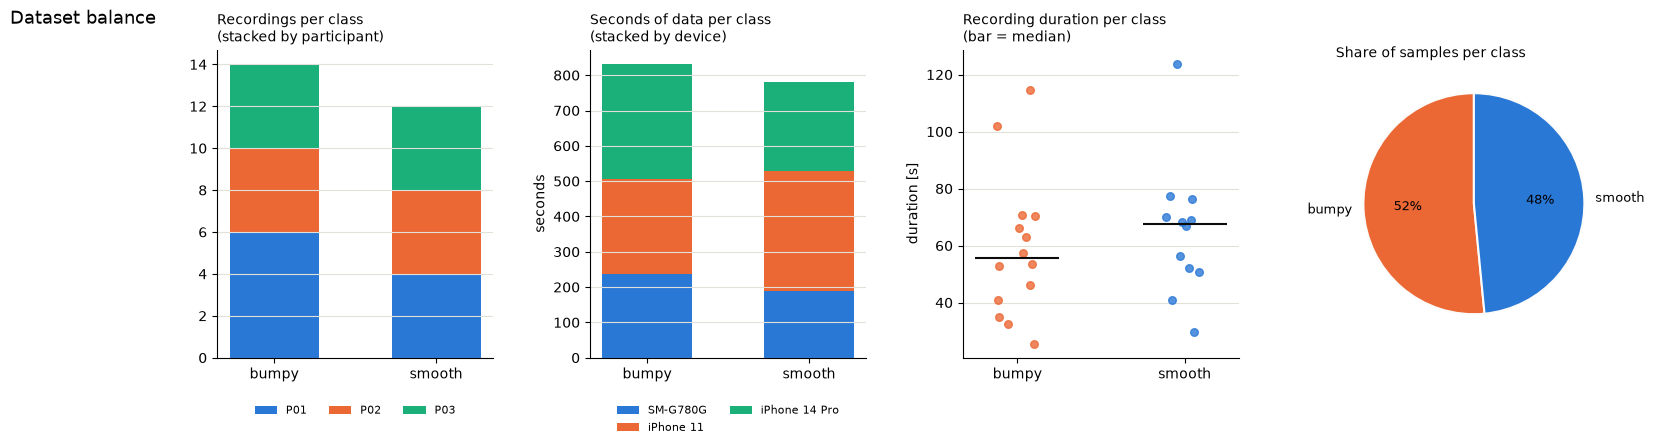

26 recordings, 26.9 min, 161026 samples


recordings  seconds
participant class                      
P01         bumpy            6    237.0
            smooth           4    188.0
P02         bumpy            4    270.0
            smooth           4    340.0
P03         bumpy            4    323.0
            smooth           4    254.0

In [168]:
CLASSES = ["bumpy", "smooth"]
UNITS = {"acc": "m/s^2 (gravity removed)", "tacc": "m/s^2", "grav": "m/s^2", "gyro": "rad/s"}

PALETTE = ["#2a78d6", "#eb6834", "#1baf7a"]
AXIS_COLOR = dict(zip("xyz", PALETTE))
CLASS_COLOR = {"bumpy": "#eb6834", "smooth": "#2a78d6"}

plt.rcParams.update({"axes.grid": True, "grid.color": "#e1e0d9", "axes.spines.top": False, "axes.spines.right": False,
                     "lines.linewidth": 1.0, "figure.dpi": 100})

summary = pd.DataFrame([{
    "recording_id": k, "class": v["label"].iloc[0], "participant": v["participant"].iloc[0],
    "device": recordings.set_index("recording_id").loc[k, "device"],
    "duration_s": v["t"].iloc[-1] - v["t"].iloc[0], "samples": len(v),
} for k, v in trimmed.items()])

fig, axes = plt.subplots(1, 4, figsize=(18, 4), gridspec_kw={"wspace": 0.35})

# (a) recordings per class, stacked by participant
ct = pd.crosstab(summary["class"], summary["participant"]).reindex(CLASSES)
part_colors = {p: PALETTE[i % len(PALETTE)] for i, p in enumerate(sorted(summary["participant"].unique()))}
bottom = np.zeros(len(ct))

for p in ct.columns:
    axes[0].bar(ct.index, ct[p], bottom=bottom, color=part_colors[p], label=p, width=0.55)
    bottom += ct[p].values
    
axes[0].set_title("Recordings per class\n(stacked by participant)", loc="left", fontsize=10)
axes[0].legend(frameon=False, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3)
axes[0].grid(axis="x", visible=False)

# (b) seconds per class, stacked by device
ct = pd.crosstab(summary["class"], summary["device"], values=summary["duration_s"], aggfunc="sum").fillna(0).reindex(CLASSES)
dev_colors = {dv: PALETTE[i % len(PALETTE)] for i, dv in enumerate(sorted(summary["device"].unique()))}
bottom = np.zeros(len(ct))

for dv in ct.columns:
    axes[1].bar(ct.index, ct[dv], bottom=bottom, color=dev_colors[dv], label=dv, width=0.55)
    bottom += ct[dv].values
    
axes[1].set_title("Seconds of data per class\n(stacked by device)", loc="left", fontsize=10)
axes[1].set_ylabel("seconds")
axes[1].legend(frameon=False, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2)
axes[1].grid(axis="x", visible=False)

# (c) duration distribution per class
rng = np.random.default_rng(0)

for i, cls in enumerate(CLASSES):
    dur = summary.loc[summary["class"] == cls, "duration_s"]
    axes[2].scatter(np.full(len(dur), i) + rng.uniform(-0.12, 0.12, len(dur)), dur,
                    color=CLASS_COLOR[cls], alpha=0.8, s=30, zorder=3)
    axes[2].hlines(dur.median(), i - 0.25, i + 0.25, color="#0b0b0b", lw=1.5, zorder=4)
    
axes[2].set_xticks(range(len(CLASSES)), CLASSES)
axes[2].set_ylabel("duration [s]")
axes[2].set_title("Recording duration per class\n(bar = median)", loc="left", fontsize=10)
axes[2].grid(axis="x", visible=False)

# (d) share of samples per class
samples = summary.groupby("class")["samples"].sum().reindex(CLASSES)

axes[3].pie(samples, labels=samples.index, colors=[CLASS_COLOR[c] for c in samples.index],
            autopct="%1.0f%%", startangle=90, wedgeprops={"linewidth": 1.5, "edgecolor": "#fcfcfb"},
            textprops={"fontsize": 9})

axes[3].set_title("Share of samples per class", loc="left", fontsize=10)
axes[3].grid(False)

fig.suptitle("Dataset balance", fontsize=13, x=0.01, ha="left")
fig.savefig(FIG_DIR / "dataset_balance.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"{len(summary)} recordings, {summary['duration_s'].sum() / 60:.1f} min, {summary['samples'].sum()} samples")
summary.groupby(["participant", "class"]).agg(recordings=("recording_id", "count"), seconds=("duration_s", "sum")).round(0)

## 1.6 Time Series Visualization

Plot selected/typed measurement: one subplot per sensor, x/y/z in fixed colours.

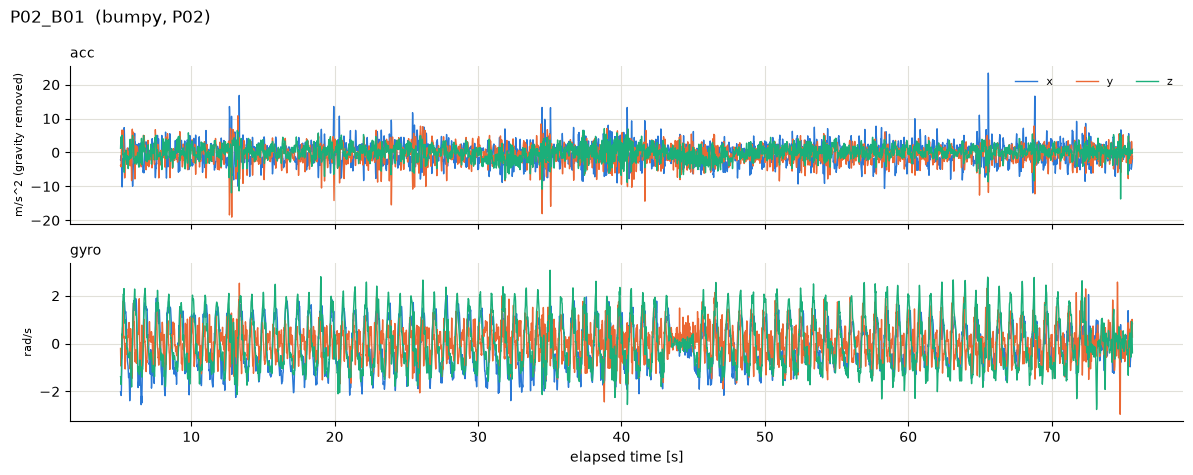

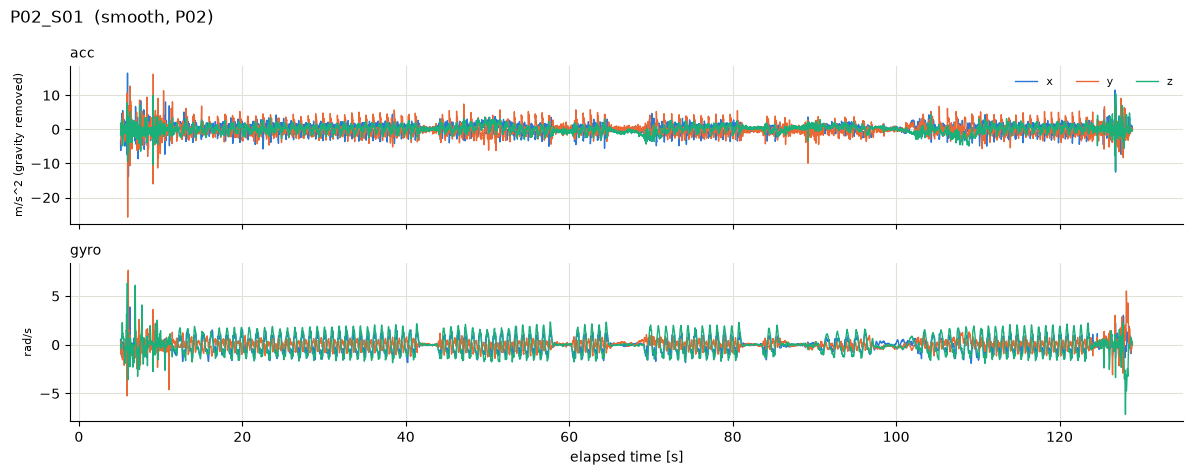

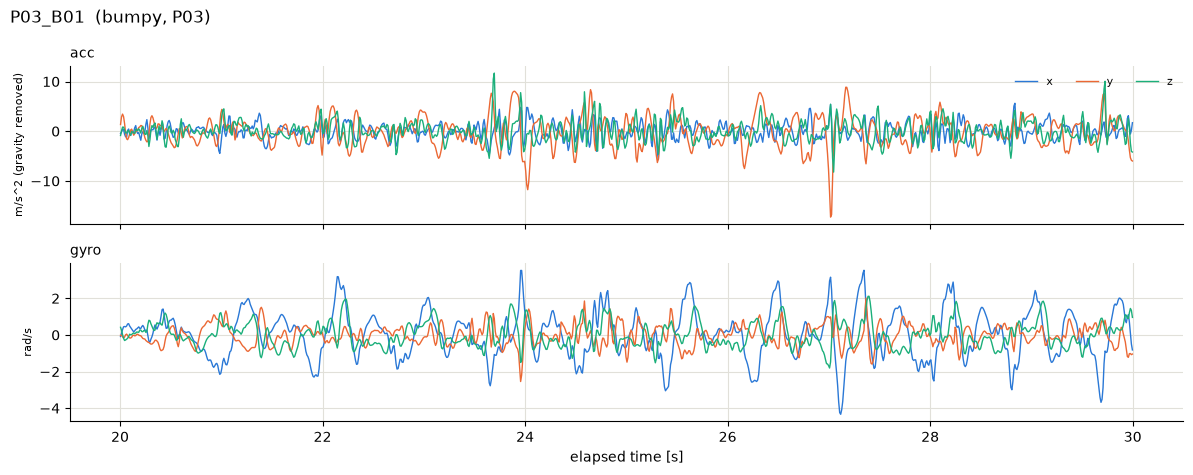

In [169]:
def plot_recording(df: pd.DataFrame, sensors=("acc", "gyro"), t_start=None, t_end=None, save=False):
    rec = df["recording_id"].iloc[0]
    if t_start is not None or t_end is not None:
        df = df[(df["t"] >= (t_start or -np.inf)) & (df["t"] <= (t_end or np.inf))]

    fig, axes = plt.subplots(len(sensors), 1, figsize=(12, 2.4 * len(sensors)), sharex=True, squeeze=False)
    for ax, s in zip(axes[:, 0], sensors):
        for a in "xyz":
            ax.plot(df["t"], df[f"{s}_{a}"], color=AXIS_COLOR[a], label=a)
        ax.set_ylabel(UNITS[s], fontsize=8)
        ax.set_title(s, loc="left", fontsize=10)
    axes[0, 0].legend(loc="upper right", ncol=3, frameon=False, fontsize=8)
    axes[-1, 0].set_xlabel("elapsed time [s]")
    fig.suptitle(f"{rec}  ({df['label'].iloc[0]}, {df['participant'].iloc[0]})", x=0.01, ha="left", fontsize=12)
    fig.tight_layout()
    if save:
        fig.savefig(FIG_DIR / f"{rec}.png", bbox_inches="tight")
    plt.show()

plot_recording(trimmed["P02_B01"])
plot_recording(trimmed["P02_S01"])
plot_recording(trimmed["P03_B01"], t_start=20, t_end=30)   # zoom on 10 s

## 1.7 Normalization 

The phone can be mounted differently in every ride, since we did not explicitly specify in the data collection protocol precisely. Therefore x,y,z have different interpretation per recording, therefore we normalize (or convert) into a orientation invariant equivalent. 

Consider: 
- `acc_mag`   = abs(acc)
- `acc_vert`  = acc projected on the gravity direction (up/down: the road-roughness signal)
- `acc_horiz` = the remaining horizontal part
- `gyro_mag`  = abs(gyro)
- `tacc_mag`  = abs(TotalAcceleration), {gravity + vibration in one number: after mean removal ~ `acc_vert`}



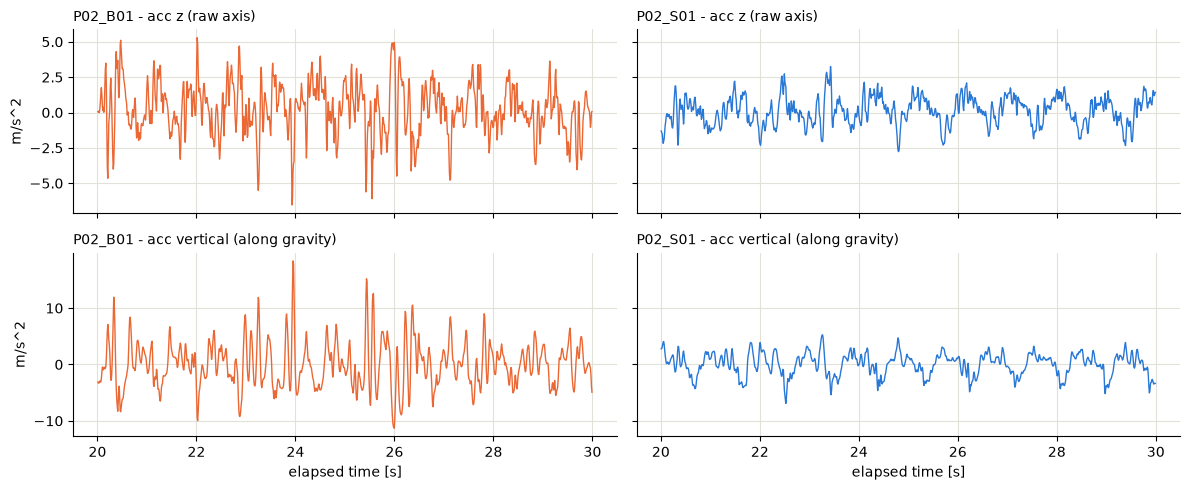

In [170]:
def add_channels(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    g = df[["grav_x", "grav_y", "grav_z"]].to_numpy()
    g = g / np.linalg.norm(g, axis=1, keepdims=True)      # Euclidean norm: unit "down" vector per sample
    
    a = df[["acc_x", "acc_y", "acc_z"]].to_numpy()
    df["acc_mag"] = np.linalg.norm(a, axis=1)             # Euclidean norm: Total intensity of movement 
    
    # Vertical acceleration isolation
    df["acc_vertical"] = (a * g).sum(axis=1)              # Dot-product: projection
    
    # Horizontal acceleration isolation
    df["acc_horizontal"] = np.sqrt(np.clip(df["acc_mag"] ** 2 - df["acc_vertical"] ** 2, 0, None)) # Pythagoras theorem
    
    df["gyro_mag"] = np.linalg.norm(df[["gyro_x", "gyro_y", "gyro_z"]].to_numpy(), axis=1)
    df["tacc_mag"] = np.linalg.norm(df[["tacc_x", "tacc_y", "tacc_z"]].to_numpy(), axis=1)
    return df

trimmed = {k: add_channels(v) for k, v in trimmed.items()}

# raw axis vs. orientation-free channel: one bumpy and one smooth ride
fig, axes = plt.subplots(2, 2, figsize=(12, 5), sharex="col", sharey="row")

for col, rec in enumerate(["P02_B01", "P02_S01"]):
    d = trimmed[rec]; d = d[(d["t"] >= 20) & (d["t"] <= 30)]
    c = CLASS_COLOR[d["label"].iloc[0]]
    
    axes[0, col].plot(d["t"], d["acc_z"], color=c);    axes[0, col].set_title(f"{rec} - acc z (raw axis)", loc="left", fontsize=10)
    axes[1, col].plot(d["t"], d["acc_vertical"], color=c); axes[1, col].set_title(f"{rec} - acc vertical (along gravity)", loc="left", fontsize=10)
    axes[1, col].set_xlabel("elapsed time [s]")
    
axes[0, 0].set_ylabel("m/s^2"); axes[1, 0].set_ylabel("m/s^2")
fig.tight_layout(); plt.show()

## 1.8 Frequency Filtering

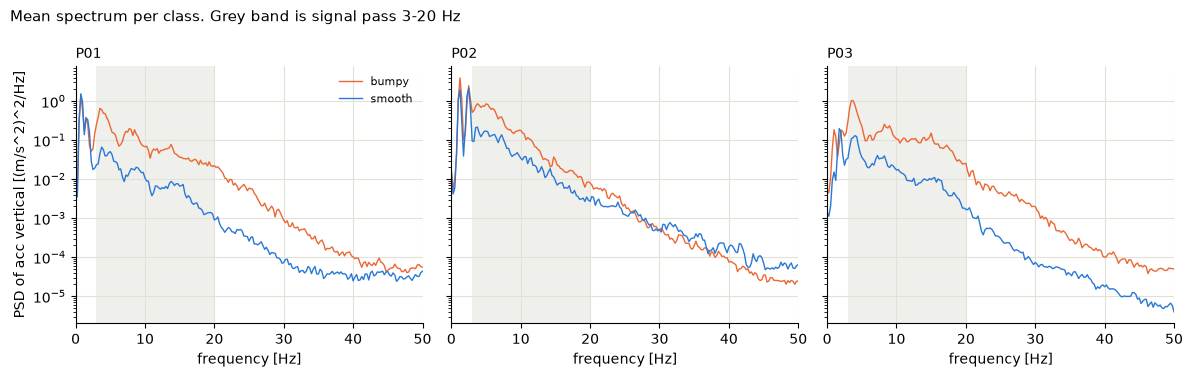

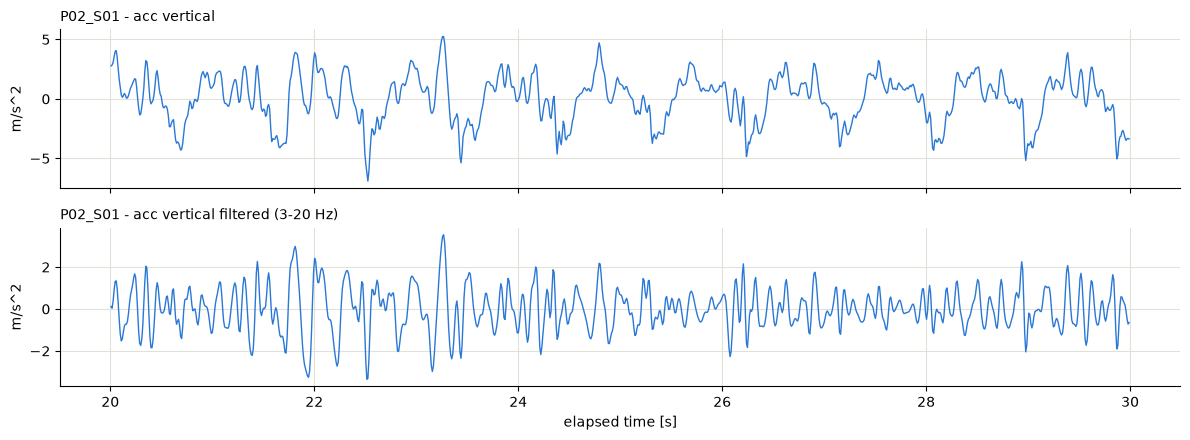

In [171]:
BAND = (3.0, 20.0) 

def bandpass(x: np.ndarray, lo: float = BAND[0], hi: float = BAND[1], fs: int = FS) -> np.ndarray:
    """Zero-phase FFT band-pass: keep only bins with lo <= f <= hi."""
    X = np.fft.rfft(x - x.mean())
    f = np.fft.rfftfreq(len(x), 1 / fs)
    X[(f < lo) | (f > hi)] = 0
    return np.fft.irfft(X, len(x))

def mean_spectrum(x: np.ndarray, fs: int = FS, n: int = 4 * FS):
    """Averaged periodogram over n-sample chunks (Hann window)."""
    x = x[: len(x) // n * n].reshape(-1, n)
    w = np.hanning(n)
    x = (x - x.mean(axis=1, keepdims=True)) * w
    psd = (np.abs(np.fft.rfft(x, axis=1)) ** 2).mean(axis=0) / (fs * (w ** 2).sum())
    return np.fft.rfftfreq(n, 1 / fs), psd

for v in trimmed.values():
    v["acc_vertical_filtered"] = bandpass(v["acc_vertical"].to_numpy())

# where does the class difference live? mean spectrum of acc_vert per class and participant
participants = sorted(recordings["participant"].unique())
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharey=True)

for ax, p in zip(axes, participants):
    for label in CLASSES:
        recs = [k for k, v in trimmed.items() if v["participant"].iloc[0] == p and v["label"].iloc[0] == label]
        f, psd = zip(*(mean_spectrum(trimmed[k]["acc_vertical"].to_numpy()) for k in recs))
        ax.semilogy(f[0], np.mean(psd, axis=0), color=CLASS_COLOR[label], label=label)
    ax.axvspan(*BAND, color="#e1e0d9", alpha=0.5, lw=0)
    ax.set_title(p, loc="left", fontsize=10); ax.set_xlabel("frequency [Hz]"); ax.set_xlim(0, FS / 2)
    
axes[0].set_ylabel("PSD of acc vertical [(m/s^2)^2/Hz]"); axes[0].legend(frameon=False, fontsize=8)
fig.suptitle(f"Mean spectrum per class. Grey band is signal pass {BAND[0]:.0f}-{BAND[1]:.0f} Hz", x=0.01, ha="left", fontsize=11)
fig.tight_layout(); plt.show()

# before / after in the time domain
fig, axes = plt.subplots(2, 1, figsize=(12, 4.5), sharex=True)
d = trimmed["P02_S01"]; d = d[(d["t"] >= 20) & (d["t"] <= 30)]

axes[0].plot(d["t"], d["acc_vertical"], color=CLASS_COLOR["smooth"]);    axes[0].set_title("P02_S01 - acc vertical", loc="left", fontsize=10)
axes[1].plot(d["t"], d["acc_vertical_filtered"], color=CLASS_COLOR["smooth"]); axes[1].set_title(f"P02_S01 - acc vertical filtered ({BAND[0]:.0f}-{BAND[1]:.0f} Hz)", loc="left", fontsize=10)
axes[1].set_xlabel("elapsed time [s]"); axes[0].set_ylabel("m/s^2"); axes[1].set_ylabel("m/s^2")
fig.tight_layout(); plt.show()

## 1.9 Windowing

We observe that road-roughness is stationary over a few seconds, so each recording is cut into **4 s windows with a 2 s step** (50 % overlap).
Windows are defined by sample count (400 samples at 100 Hz): the timestamps are regular enough for that

Output: `X` of shape `(n_windows, 400, n_channels)` and `windows` (one row of metadata per window). `recording_id` and
`participant` stay attached to every window so the split can be made by ride / by participant later.

(Smoothing such as a moving average is *not* applied: Due to road texture we want to maintain)

X: (768, 400, 5)  (windows, samples, channels=['acc_vertical', 'acc_vertical_filtered', 'acc_horizontal', 'gyro_mag', 'tacc_mag'])


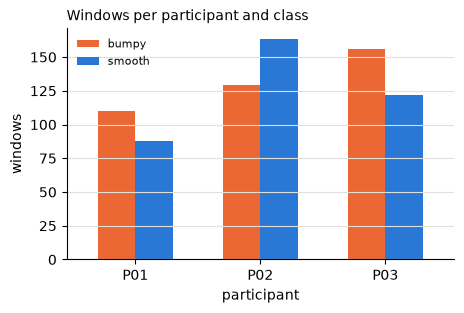

label,bumpy,smooth
participant,,
P01,110,88
P02,129,163
P03,156,122


In [172]:
WIN_S, STEP_S = 4, 2
WIN, STEP = WIN_S * FS, STEP_S * FS
CHANNELS = ["acc_vertical", "acc_vertical_filtered", "acc_horizontal", "gyro_mag", "tacc_mag"]

def make_windows(df: pd.DataFrame, win: int = WIN, step: int = STEP, channels=CHANNELS):
    """Return (array of shape (n, win, len(channels)), list of metadata dicts)."""
    arr = df[channels].to_numpy(np.float32)
    starts = range(0, len(df) - win + 1, step)
    
    X = np.stack([arr[s:s + win] for s in starts]) if len(df) >= win else np.empty((0, win, len(channels)), np.float32)
    
    meta = [{"window_id": f"{df['recording_id'].iloc[0]}_W{i:03d}", "recording_id": df["recording_id"].iloc[0],
             "participant": df["participant"].iloc[0], "label": df["label"].iloc[0], "t_start": df["t"].iloc[s]}
            for i, s in enumerate(starts)]
    return X, meta

Xs, metas = zip(*(make_windows(v) for v in trimmed.values()))
X = np.concatenate(Xs)
windows = pd.DataFrame([m for mm in metas for m in mm])
print(f"X: {X.shape}  (windows, samples, channels={CHANNELS})")

counts = windows.groupby(["participant", "label"]).size().unstack().reindex(columns=CLASSES)
ax = counts.plot.bar(color=[CLASS_COLOR[c] for c in CLASSES], width=0.6, figsize=(5, 3), rot=0)
ax.set_ylabel("windows"); ax.set_title("Windows per participant and class", loc="left", fontsize=10)
ax.legend(frameon=False, fontsize=8); ax.grid(axis="x", visible=False); plt.show()

counts

## 1.10 Window Statistics

Statistical computations: 
- vert_std: Standard deviation of vertical acceleration (measures overall movement intensity).
- vert_iqr: Interquartile range of vertical acceleration (spread of the middle 50% of the data, robust to outliers).
- vert_p2p: Peak-to-peak amplitude (maximum minus minimum value).
- vert_p95abs: 95th percentile of the absolute acceleration (captures maximum intensity while ignoring extreme anomalies).
- vert_madiff: Mean absolute difference of consecutive samples (measures signal jerkiness or high-frequency changes).
- gyro_std: Variance in rotational speed.
- gyro_mean: Average rotational speed.

In [173]:
def basic_stats(w: np.ndarray) -> dict:
    """w: one window, shape (samples, channels) in CHANNELS order."""
    v = w[:, CHANNELS.index("acc_vertical_filtered")]
    g = w[:, CHANNELS.index("gyro_mag")]
    
    return {
        "vert_std": v.std(), "vert_iqr": np.subtract(*np.percentile(v, [75, 25])), "vert_p2p": np.ptp(v),
        "vert_p95abs": np.percentile(np.abs(v), 95), "vert_madiff": np.abs(np.diff(v)).mean(),
        "gyro_std": g.std(), "gyro_mean": g.mean(),
    }

stats = pd.concat([windows, pd.DataFrame([basic_stats(w) for w in X])], axis=1)
STAT_COLS = [c for c in stats.columns if c not in windows.columns]

print("per class (mean over windows):")
display(stats.groupby("label")[STAT_COLS].mean().reindex(CLASSES).round(3))

print("per participant and class:")
stats.groupby(["participant", "label"])[STAT_COLS].agg(["mean", "std"]).round(3)

per class (mean over windows):


,vert_std,vert_iqr,vert_p2p,vert_p95abs,vert_madiff,gyro_std,gyro_mean
label,,,,,,,
bumpy,2.372,2.918,15.392,4.705,0.869,0.575,1.187
smooth,0.940,1.115,6.348,1.903,0.348,0.579,1.176


per participant and class:


vert_std        vert_iqr        vert_p2p         \
                       mean    std     mean    std     mean    std   
participant label                                                    
P01         bumpy     1.986  0.451    2.568  0.523   11.956  3.539   
            smooth    0.662  0.178    0.803  0.157    4.462  1.917   
P02         bumpy     2.785  0.646    3.331  0.615   18.614  6.643   
            smooth    1.190  0.456    1.398  0.462    8.053  4.192   
P03         bumpy     2.303  0.657    2.823  0.857   15.151  5.196   
            smooth    0.807  0.340    0.961  0.318    5.429  2.860   

                   vert_p95abs        vert_madiff        gyro_std         \
                          mean    std        mean    std     mean    std   
participant label                                                          
P01         bumpy        3.905  0.963       0.783  0.133    0.541  0.047   
            smooth       1.334  0.411       0.255  0.055    0.565  0.054   
P02         bumpy        5.527  1.416       0.892  0.179    0.646  0.041   
            smooth       2.407  0.963       0.417  0.139    0.743  0.380   
P03         bumpy        4.589  1.360       0.910  0.268    0.540  0.265   
            smooth       1.639  0.768       0.322  0.110    0.370  0.333   

                   gyro_mean         
                        mean    std  
participant label                    
P01         bumpy      1.157  0.100  
            smooth     1.153  0.101  
P02         bumpy      1.460  0.138  
            smooth     1.505  0.633  
P03         bumpy      0.981  0.346  
            smooth     0.753  0.657

## 1.11 Interim Backup of Pre-Processed Data

Everything downstream (features, models) starts from these two files later so it is useful to backup at this stage.

In [174]:
PROC_DIR = Path("./artifacts")
PROC_DIR.mkdir(exist_ok=True)

np.savez_compressed(PROC_DIR / "windows.npz", X=X, channels=np.array(CHANNELS), fs=FS, win_s=WIN_S, step_s=STEP_S, band=np.array(BAND))
windows.to_csv(PROC_DIR / "windows_meta.csv", index=False)

print(f"saved {X.shape} -> {PROC_DIR / 'windows.npz'}  ({(PROC_DIR / 'windows.npz').stat().st_size / 1e6:.1f} MB)")
print(f"saved {len(windows)} rows -> {PROC_DIR / 'windows_meta.csv'}")

saved (768, 400, 5) -> artifacts\windows.npz  (3.0 MB)
saved 768 rows -> artifacts\windows_meta.csv


---
*Copied from `notebooks/features_and_selection.ipynb`*

# 2) Feature Engineering

Reads `artifacts/windows.npz` (produced by the exploration notebook). 


Steps of feature-engineering: 
 
1. extract a broad set of candidate features per window
2. **split grouped by recording** (never by window)
3. filters: variance threshold, correlation, Fisher scatter score, mutual information
4. wrapper: greedy forward selection on cross-validated error rate
5. extraction: PCA
6. summary


In [175]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import LeaveOneGroupOut

PROC_DIR = Path("./artifacts")
FIG_DIR = Path("./figures")

z = np.load(PROC_DIR / "windows.npz")
X_raw, CHANNELS, FS = z["X"], list(z["channels"]), int(z["fs"])
meta = pd.read_csv(PROC_DIR / "windows_meta.csv")
y = (meta["label"] == "bumpy").to_numpy().astype(int)      # 1 = bumpy, 0 = smooth

print(f"X_raw {X_raw.shape}, channels {CHANNELS}, {FS} Hz, {y.sum()} bumpy / {(1 - y).sum()} smooth windows")

CLASSES = ["bumpy", "smooth"]
CLASS_COLOR = {"bumpy": "#eb6834", "smooth": "#2a78d6"}
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a"]
plt.rcParams.update(
    {"axes.grid": True, "grid.color": "#e1e0d9",
     "axes.spines.top": False, "axes.spines.right": False,
     "lines.linewidth": 1.0, "figure.dpi": 100})

X_raw (768, 400, 5), channels [np.str_('acc_vertical'), np.str_('acc_vertical_filtered'), np.str_('acc_horizontal'), np.str_('gyro_mag'), np.str_('tacc_mag')], 100 Hz, 395 bumpy / 373 smooth windows


## 2.1 Common Features Extraction

Per window and channel: time-domain statistics

In [176]:
BANDS = [(0.5, 3), (3, 8), (8, 15), (15, 30), (30, 50)]

# 8 temporal statistical features 
def time_feats(x, name):
    x = x - x.mean();       #Zero-Mean Normalization
    s = x.std() + 1e-12 
    
    return {f"{name}_std": x.std(), f"{name}_iqr": np.subtract(*np.percentile(x, [75, 25])), f"{name}_p2p": np.ptp(x),
            f"{name}_p95abs": np.percentile(np.abs(x), 95), f"{name}_madiff": np.abs(np.diff(x)).mean(),
            f"{name}_kurt": ((x / s) ** 4).mean(), f"{name}_skew": ((x / s) ** 3).mean(),
            f"{name}_zcr": (np.diff(np.sign(x)) != 0).mean()}

def spec_feats(x, name):
    w = np.hanning(len(x))
    P = np.abs(np.fft.rfft((x - x.mean()) * w)) ** 2
    f = np.fft.rfftfreq(len(x), 1 / FS)
    
    tot = P[f >= 0.5].sum() + 1e-12
    out = {}
    
    for lo, hi in BANDS:
        out[f"{name}_bp{lo}-{hi}"] = P[(f >= lo) & (f < hi)].sum()           # absolute band power
        out[f"{name}_bf{lo}-{hi}"] = out[f"{name}_bp{lo}-{hi}"] / tot        # fraction of total
        
    p = P[f >= 0.5] / tot
    out[f"{name}_centroid"] = (f[f >= 0.5] * p).sum()
    out[f"{name}_domfreq"] = f[f >= 0.5][p.argmax()]
    out[f"{name}_spec_entropy"] = -(p[p > 0] * np.log(p[p > 0])).sum()
    return out

def extract_features(w):
    """w: one window (samples, channels) in CHANNELS order -> dict of features."""
    ch = {c: w[:, i] for i, c in enumerate(CHANNELS)}
    return (time_feats(ch["acc_vertical"], "vert") 
            | time_feats(ch["acc_vertical_filtered"], "vertbp") | time_feats(ch["acc_horizontal"], "horiz")
            | time_feats(ch["gyro_mag"], "gyro") | time_feats(ch["tacc_mag"], "tacc")
            | spec_feats(ch["acc_vertical"], "vert") | spec_feats(ch["gyro_mag"], "gyro"))

feat = pd.DataFrame([extract_features(w) for w in X_raw])
FEATS = list(feat.columns)
X = feat.to_numpy(float)

print(f"{len(FEATS)} candidate features for {len(feat)} windows")
feat.describe().T.round(3).head(12)

66 candidate features for 768 windows


,count,mean,std,min,25%,50%,75%,max
vert_std,768.0,2.274,0.981,0.503,1.513,2.238,2.866,5.218
vert_iqr,768.0,2.885,1.240,0.612,2.051,2.835,3.683,6.450
vert_p2p,768.0,13.791,7.335,2.937,8.679,12.683,17.461,45.429
vert_p95abs,768.0,4.457,1.937,0.939,2.969,4.361,5.535,10.543
vert_madiff,768.0,0.667,0.332,0.190,0.360,0.629,0.912,1.915
vert_kurt,768.0,3.812,3.009,1.947,2.756,3.153,3.951,54.986
vert_skew,768.0,0.008,0.578,-1.572,-0.386,-0.021,0.319,3.777
vert_zcr,768.0,0.118,0.048,0.018,0.080,0.118,0.155,0.268
vertbp_std,768.0,1.677,0.917,0.391,0.857,1.537,2.336,4.410
vertbp_iqr,768.0,2.042,1.099,0.497,1.016,1.878,2.949,5.369


## 2.2 Data Splitting: 

Cross-validation splitting strategy where we keep in mind that time windows from same measurements should not be combined. Since this would result in data set leakage. 

A fold is a subset where we isolate it to prevent data leakage during training.

In [177]:
N_FOLDS = 4

sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=0)
y_composite = meta["participant"].astype(str) + "_" + meta["label"]
fold_of_window = np.zeros(len(meta), dtype=int)

for fold_idx, (train_idx, test_idx) in enumerate(sgkf.split(X=meta, y=y_composite, groups=meta["recording_id"])):
    fold_of_window[test_idx] = fold_idx

# Assign back to your dataset
meta["fold"] = fold_of_window

print("windows per fold and class:")
display(pd.crosstab(meta["fold"], meta["label"]))

windows per fold and class:


label,bumpy,smooth
fold,,
0,78,112
1,117,71
2,115,84
3,85,106


In [178]:
# split iterators: each yields (train_mask, test_mask) over windows
def grouped_splits():
    for k in range(N_FOLDS):
        yield fold_of_window != k, fold_of_window == k

def lopo_splits():
    for p in np.unique(part_of_window):
        yield part_of_window != p, part_of_window == p

# sanity check: no recording appears in both train and test of any grouped fold
for tr, te in grouped_splits():
    assert not set(meta.loc[tr, "recording_id"]) & set(meta.loc[te, "recording_id"])
    
print("grouped folds are leak-free at the recording level")

grouped folds are leak-free at the recording level


## 2.3 Filtering of Feature Selection

1. Variance threshold: Drop constant features (like dead sensors we discussed in lecture)
2. Correlation drop: Of every pair keep one with r > 0.95, the other one does not have new information
3. Relevance score: Fisher scatter score, $(m_1-m_0)^2/(s_1^2+s_0^2)$

In [179]:
# Variance threshold
var = feat.var()
dead = var[var < 1e-10].index.tolist()
kept = [f for f in FEATS if f not in dead]
print(f"[variance] removed {len(dead)}: {dead}")

# 2. correlation pruning (label-free). Of a redundant pair keep the feature from the preferred channel:
#    the band-passed vertical channel was designed for this task, gyro is the least informative.

R_THR = 0.95
PRIORITY = ["vertbp", "vert", "tacc", "horiz", "gyro"]
prio = lambda f: (PRIORITY.index(f.split("_")[0]), f)
C = feat[kept].corr().abs()
pairs = sorted(((C.loc[a, b], a, b) for i, a in enumerate(kept) for b in kept[i + 1:] if C.loc[a, b] > R_THR), reverse=True)

for r, a, b in pairs:
    if a in kept and b in kept:
        kept.remove(max(a, b, key=prio))
removed = [f for f in FEATS if f not in kept and f not in dead]

print(f"[correlation] {len(pairs)} pairs with |r| > {R_THR}: {len(removed)} features removed, {len(kept)} left")
print(f"               removed: {removed}")

[variance] removed 0: []
[correlation] 22 pairs with |r| > 0.95: 14 features removed, 52 left
               removed: ['vert_std', 'vert_p2p', 'vert_madiff', 'vertbp_std', 'horiz_std', 'gyro_std', 'tacc_std', 'tacc_iqr', 'tacc_p2p', 'tacc_p95abs', 'tacc_madiff', 'tacc_kurt', 'tacc_skew', 'tacc_zcr']


## 2.4 PCA of top Features 

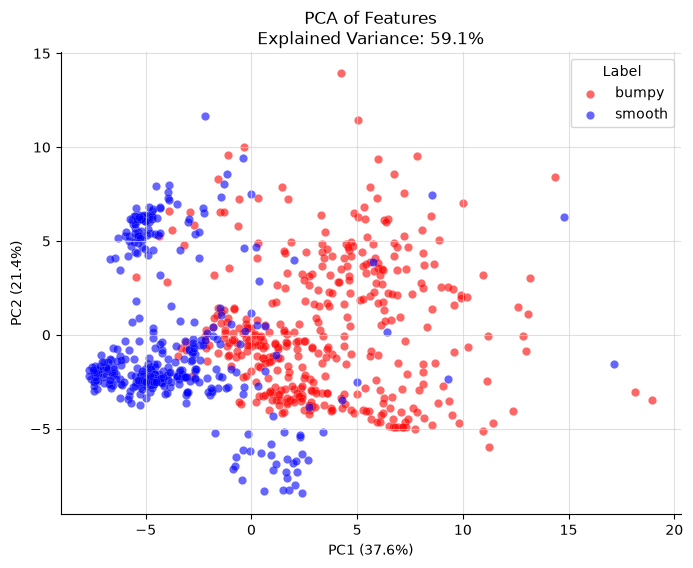

In [180]:
mask_bumpy = meta['label'] == 'bumpy'
mask_smooth = meta['label'] == 'smooth'

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply PCA
pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X_scaled)

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(X_pca[mask_bumpy, 0], X_pca[mask_bumpy, 1], 
           c='red', label='bumpy', alpha=0.6, edgecolors='w', linewidth=0.15)

ax.scatter(X_pca[mask_smooth, 0], X_pca[mask_smooth, 1], 
           c='blue', label='smooth', alpha=0.6, edgecolors='w', linewidth=0.15)

# Formatting
ax.set_title(f"PCA of Features\nExplained Variance: {pca.explained_variance_ratio_.sum()*100:.1f}%")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.legend(title='Label')
ax.grid(True, color='lightgray', alpha=0.7)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig('./figures/PCA_features.png')
plt.show()

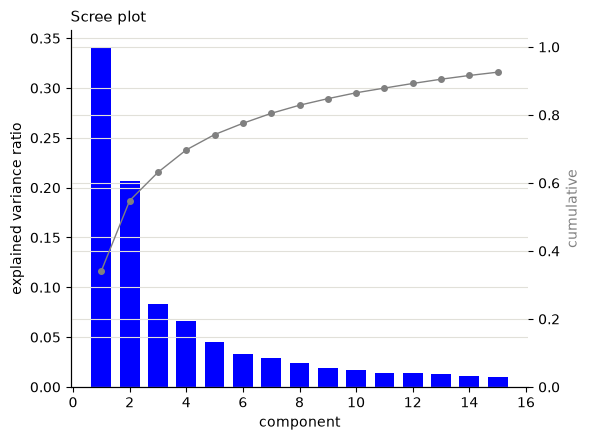

In [181]:
idx = [FEATS.index(c) for c in kept]
Zall = (X[:, idx] - X[:, idx].mean(0)) / (X[:, idx].std(0) + 1e-9)

# Compute eigenvalues to get the explained variance
ev, _ = np.linalg.eigh(np.cov(Zall.T))
order = ev.argsort()[::-1]
ev = ev[order]
ratio = ev / ev.sum()

# Scree Plot
fig, ax = plt.subplots(figsize=(6, 4.5))

# Plot individual explained variance (bars)
ax.bar(range(1, 16), ratio[:15], color="blue", width=0.7)
ax.set_xlabel("component")
ax.set_ylabel("explained variance ratio")
ax.set_title("Scree plot", loc="left", fontsize=11)
ax.grid(axis="x", visible=False)
ax.spines['top'].set_visible(False)

# Plot cumulative explained variance (line)
ax2 = ax.twinx()
ax2.plot(range(1, 16), np.cumsum(ratio[:15]), color="gray", marker="o", markersize=4)
ax2.set_ylim(0, 1.05)
ax2.set_ylabel("cumulative", color="gray")
ax2.spines['top'].set_visible(False)

fig.tight_layout()
plt.show()

- Mean Fisher score: Ranking metric, where higher number implies that the two classes have different noticeable average values. 
- MI_bits: Mutual information, the closer to 1 the more certain of the difference we are
- Fisher min fold: Lowest fisher score aross any of training folds. Worst-case scenario check
- Stability: Counts how many times the feature actually was in this rank across the folds

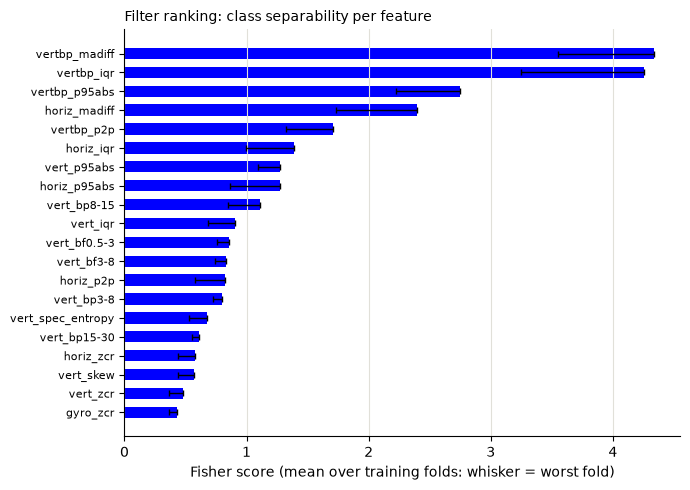

,fisher,MI_bits,fisher_min_fold,stability
feature,,,,
vertbp_madiff,4.333,0.739,3.550,4
vertbp_iqr,4.254,0.717,3.251,4
vertbp_p95abs,2.751,0.633,2.223,4
horiz_madiff,2.394,0.611,1.734,4
vertbp_p2p,1.704,0.540,1.322,4
horiz_iqr,1.392,0.427,0.998,4
vert_p95abs,1.275,0.383,1.096,4
horiz_p95abs,1.274,0.465,0.865,4
vert_bp8-15,1.113,0.611,0.847,4


In [182]:
# 3. relevance, computed on training folds only
def fisher(x, y):
    return (x[y == 1].mean() - x[y == 0].mean()) ** 2 / (x[y == 1].var() + x[y == 0].var() + 1e-12)

def mutual_info(x, y, bins=10):
    edges = np.quantile(x, np.linspace(0, 1, bins + 1))
    xb = np.clip(np.searchsorted(edges, x, side="right") - 1, 0, bins - 1)
    pxy = np.histogram2d(xb, y, bins=[bins, 2])[0] / len(x)
    px, py = pxy.sum(1, keepdims=True), pxy.sum(0, keepdims=True)
    nz = pxy > 0
    return (pxy[nz] * np.log2(pxy[nz] / (px @ py)[nz])).sum()        # bits: label entropy is ~1 bit

rows = []
for k, (tr, _) in enumerate(grouped_splits()):
    for f in kept:
        rows.append({"fold": k, "feature": f, "fisher": fisher(X[tr][:, FEATS.index(f)], y[tr]),
                     "MI_bits": mutual_info(X[tr][:, FEATS.index(f)], y[tr])})
        
rel = pd.DataFrame(rows)
top10_per_fold = rel.groupby("fold").apply(lambda d: set(d.nlargest(10, "fisher")["feature"]), include_groups=False)
scores = rel.groupby("feature")[["fisher", "MI_bits"]].mean()
scores["fisher_min_fold"] = rel.groupby("feature")["fisher"].min()
scores["stability"] = [sum(f in s for s in top10_per_fold) for f in scores.index]
scores = scores.sort_values("fisher", ascending=False)

fig, ax = plt.subplots(figsize=(7, 5))
top = scores.head(20)

ax.barh(range(len(top))[::-1], top["fisher"], color="blue", height=0.6)
ax.errorbar(top["fisher"], range(len(top))[::-1], xerr=[top["fisher"] - top["fisher_min_fold"], np.zeros(len(top))],
            fmt="none", ecolor="black", elinewidth=1, capsize=2)

ax.set_yticks(range(len(top))[::-1], top.index, fontsize=8); ax.set_xlabel("Fisher score (mean over training folds: whisker = worst fold)")
ax.set_title("Filter ranking: class separability per feature", loc="left", fontsize=10); ax.grid(axis="y", visible=False)

fig.tight_layout(); fig.savefig(FIG_DIR / "feature_fisher.png", dpi=120, bbox_inches="tight"); plt.show()

scores.head(15).round(3)

## 2.5 Export

- `features.csv`: one row per window with metadata, `fold` and all candidate features
- `feature_scores.csv`: Fisher, MI, worst-fold Fisher and stability per kept feature
- `feature_selection.json`: feature lists from each filter step

In [183]:
out = pd.concat([meta.reset_index(drop=True), feat.reset_index(drop=True)], axis=1)
assert len(out) == len(X_raw) and (out["label"] == np.where(y == 1, "bumpy", "smooth")).all()
out.to_csv(PROC_DIR / "features.csv", index=False)

scores.rename_axis("feature").to_csv(PROC_DIR / "feature_scores.csv")

selection = {"n_windows": len(out), "n_folds": N_FOLDS, "corr_threshold": R_THR,
             "all": FEATS, "variance_removed": dead, "correlation_removed": removed,
             "kept": kept, "ranked_by_fisher": scores.index.tolist()}
(PROC_DIR / "feature_selection.json").write_text(json.dumps(selection, indent=2))

print(f"features.csv            {out.shape}")
print(f"feature_scores.csv      {scores.shape}")
print(f"feature_selection.json  {len(kept)} kept of {len(FEATS)}")

features.csv            (768, 72)
feature_scores.csv      (52, 4)
feature_selection.json  52 kept of 66


---
*Copied from `notebooks/kmeans_clustering.ipynb`*

# 3) k-means clustering

- Type of model: UNSUPERVISED
- Model type of approach: feature-space clustering


In [184]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, silhouette_score
from sklearn.metrics import confusion_matrix

PROC_DIR = Path("./artifacts")
FIG_DIR = Path("./figures")
RESULTS_DIR = PROC_DIR / "results"
RESULTS_DIR.mkdir(exist_ok=True)

df = pd.read_csv(PROC_DIR / "features.csv")
sel = json.loads((PROC_DIR / "feature_selection.json").read_text())
y = (df["label"] == "bumpy").to_numpy().astype(int)      # 1 = bumpy, 0 = smooth
N_FOLDS = sel["n_folds"]

print(f"{len(df)} windows, {df['recording_id'].nunique()} recordings, {df['participant'].nunique()} participants")
print(f"{len(sel['kept'])} features kept by the filters, {len(sel['all'])} candidates")

CLASSES = ["bumpy", "smooth"]
CLASS_COLOR = {"bumpy": "orange", "smooth": "blue"}
PALETTE = ["blue", "orange", "green"]

plt.rcParams.update(
    {"axes.grid": True, "grid.color": "gray",
     "axes.spines.top": False, "axes.spines.right": False,
     "lines.linewidth": 1.0, "figure.dpi": 100})

768 windows, 26 recordings, 3 participants
52 features kept by the filters, 66 candidates


## 3.1 Preprocessing

K-means uses Euclidean distance. Thus is sensitive to two things:

- **scale**: a feature with a large range dominates the distance, hence standardisation
- **skew**: A few extreme windows can pull a centroid towards one direction. With log transform these features roughly symmetric first. (Only for band-power/kurtosis features, which arent in the top 5 features)


In [185]:
LOG_FEATS = [f for f in sel["all"] if "_bp" in f or f.endswith("_kurt")]

def transform(frame, feats):
    Z = frame[feats].copy()
    for f in set(feats) & set(LOG_FEATS):
        Z[f] = np.log(Z[f] + 1e-12)
    return Z.to_numpy(float)

# feature sets, from small and interpretable to everything the filters kept
FEATURE_SETS = {
    "2D: vertbp_madiff + horiz_madiff": ["vertbp_madiff", "horiz_madiff"],
    "top-5 Fisher": sel["ranked_by_fisher"][:5],
    f"all kept ({len(sel['kept'])})": sel["kept"],
}

for name, feats in FEATURE_SETS.items():
    print(f"{name:35s} {feats if len(feats) <= 5 else '...'}")

2D: vertbp_madiff + horiz_madiff    ['vertbp_madiff', 'horiz_madiff']
top-5 Fisher                        ['vertbp_madiff', 'vertbp_iqr', 'vertbp_p95abs', 'horiz_madiff', 'vertbp_p2p']
all kept (52)                       ...


## 3.2 Determination of $k$

- **Inertia** (within-cluster sum of squares) decreases with $k$: we look for the elbow where adding a cluster stops helping much.
- **Silhouette** $s = (b-a)/\max(a,b)$ per window, with $a$ the mean distance to its own cluster and $b$ to the nearest other cluster. Closer to 1 means compact, well-separated clusters.

We know there are two road types, but the data does not have to agree: it might for example: split per participant or per ride first. Maybe interesting to discuss that it might even differ per device, or bike. 

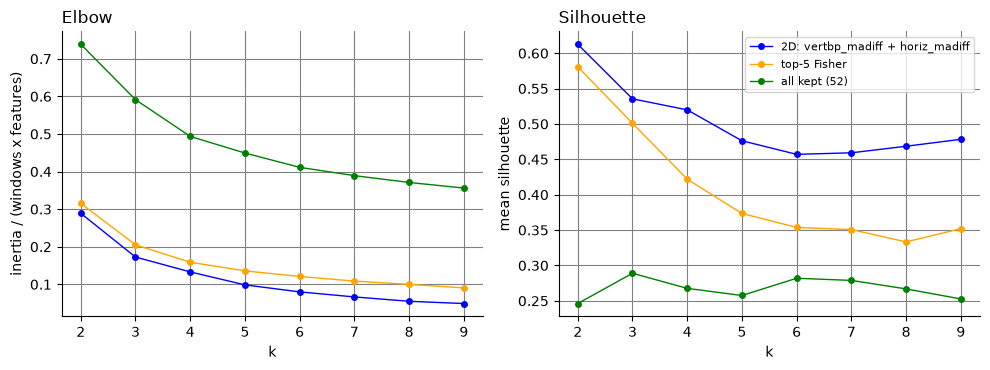

In [186]:
K_RANGE = range(2, 10)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.8))

for (name, feats), color in zip(FEATURE_SETS.items(), PALETTE):
    Z = StandardScaler().fit_transform(transform(df, feats))
    norm_factor = len(Z) * Z.shape[1] # Pre-calculate to keep loop clean
    
    inertia, sil = [], []
    for k in K_RANGE:
        km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(Z)
        
        inertia.append(km.inertia_ / norm_factor)
        
        # Added sample_size fixes performance freezing
        sil.append(silhouette_score(Z, km.labels_, sample_size=10000, random_state=0)) 
        
    plot_kws = dict(marker="o", markersize=4, color=color, label=name)
    ax1.plot(K_RANGE, inertia, **plot_kws)
    ax2.plot(K_RANGE, sil, **plot_kws)

# formatting 
ax1.set(xlabel="k", ylabel="inertia / (windows x features)", title="Elbow")
ax2.set(xlabel="k", ylabel="mean silhouette", title="Silhouette")
ax2.legend(fontsize=8)

for ax in (ax1, ax2): 
    ax.title.set(ha="left", x=0)

fig.tight_layout()
fig.savefig(FIG_DIR / "kmeans_choose_k.png", dpi=120, bbox_inches="tight")
plt.show()

## 3.3 $k = 2$ with two dimensions

With two features the algorithm creates: the centroids, and the boundary between them. 

We mark colour is the **true** label, background colour is the **cluster**.

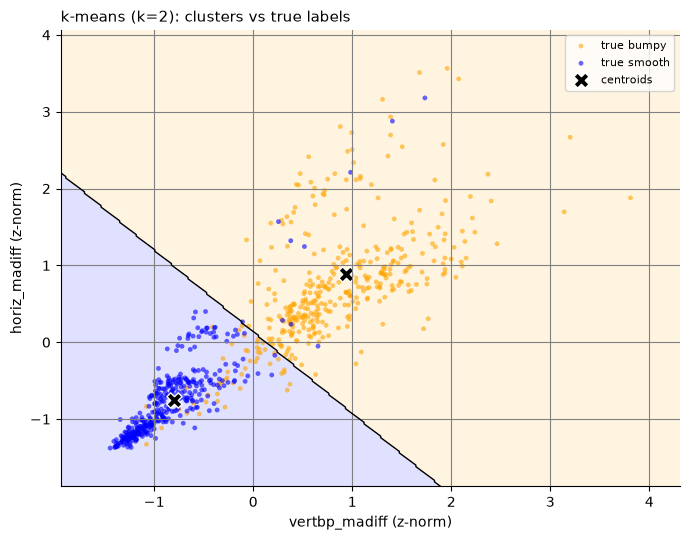

true label                bumpy  smooth
cluster (majority label)               
bumpy                       344      10
smooth                       51     363


In [187]:
feats2 = FEATURE_SETS["2D: vertbp_madiff + horiz_madiff"]
scaler2 = StandardScaler().fit(transform(df, feats2))
Z2 = scaler2.transform(transform(df, feats2))
km2 = KMeans(n_clusters=2, n_init=10, random_state=0).fit(Z2)

# naming each cluster after majority label inside it (only for colouring)
cl_name = {c: CLASSES[0] if y[km2.labels_ == c].mean() > 0.5 else CLASSES[1] for c in range(2)}

g0, g1 = np.meshgrid(np.linspace(Z2[:, 0].min() - 0.5, Z2[:, 0].max() + 0.5, 300),
                     np.linspace(Z2[:, 1].min() - 0.5, Z2[:, 1].max() + 0.5, 300))
grid_cl = km2.predict(np.c_[g0.ravel(), g1.ravel()]).reshape(g0.shape)

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.contourf(g0, g1, grid_cl, levels=[-0.5, 0.5, 1.5], alpha=0.12,
            colors=[CLASS_COLOR[cl_name[0]], CLASS_COLOR[cl_name[1]]])
ax.contour(g0, g1, grid_cl, levels=[0.5], colors="black", linewidths=1)

for lab in CLASSES:
    m = df["label"] == lab
    ax.scatter(Z2[m, 0], Z2[m, 1], s=12, alpha=0.6, color=CLASS_COLOR[lab], edgecolors="none", label=f"true {lab}")
    
ax.scatter(*km2.cluster_centers_.T, marker="X", s=120, color="black", edgecolors="white", label="centroids")
ax.set(xlabel=f"{feats2[0]} (z-norm)", ylabel=f"{feats2[1]} (z-norm)")
ax.set_title("k-means (k=2): clusters vs true labels", loc="left", fontsize=11)
ax.legend(fontsize=8)

fig.tight_layout(); fig.savefig(FIG_DIR / "kmeans_2d.png", dpi=120, bbox_inches="tight"); plt.show()

print(pd.crosstab(
    pd.Series(km2.labels_, name="cluster").map(cl_name).rename("cluster (majority label)"),
    df["label"].rename("true label")))

## 3.4 Do the clusters match the labels?

Fitted on all windows (no labels involved in the fit so still unsupervised).

Metric to evaluate with labels:

- **Purity**: map every cluster to its majority label and count how many windows then match. For $k=2$ on balanced classes, 0.5 is chance by random.
- **Adjusted Rand index (ARI)**: agreement between two partitions, corrected for chance. 0 = random, 1 = identical. Unlike purity it does not reward using many clusters.

We also check $k=3$ and $k=4$: if the extra clusters split a class into sub-groups (for instance per participant) rather than mixing classes, purity stays high while ARI drops.

In [188]:
def purity(clusters, y):
    return sum(max((y[clusters == c] == 1).sum(), (y[clusters == c] == 0).sum()) for c in np.unique(clusters)) / len(y)

rows = []
for name, feats in FEATURE_SETS.items():
    Z = StandardScaler().fit_transform(transform(df, feats))
    for k in [2, 3, 4]:
        cl = KMeans(n_clusters=k, n_init=10, random_state=0).fit_predict(Z)
        rows.append({"feature set": name, "k": k, "purity": purity(cl, y),
                     "ARI vs label": adjusted_rand_score(y, cl),
                     "ARI vs participant": adjusted_rand_score(df["participant"], cl)})

agreement = pd.DataFrame(rows).set_index(["feature set", "k"])
agreement.round(3)

purity  ARI vs label  ARI vs participant
feature set                      k                                          
2D: vertbp_madiff + horiz_madiff 2   0.921         0.707              -0.002
                                 3   0.914         0.502               0.036
                                 4   0.909         0.451               0.021
top-5 Fisher                     2   0.915         0.690              -0.001
                                 3   0.919         0.524               0.009
                                 4   0.893         0.413               0.008
all kept (52)                    2   0.862         0.523               0.018
                                 3   0.773         0.238               0.195
                                 4   0.871         0.306               0.232

## 3.5 Micro-level evaluation: K-means conversion to classifier 

For comparison with supervised models, k-means is turned into a classifier:

1. fit the scaler and k-means ($k=2$) on the **training** windows only
2. name each cluster after the majority label of the training windows in it (the only place labels are used so now it is supervised)
3. assign each test window to its nearest centroid

Two splits: the grouped folds from feature-selection step (unseen recordings) and leave-one-participant-out (unseen rider). 

The baseline is the single-feature threshold on `vertbp_madiff` (midpoint between the class medians of the training data). Just a simple heuristic which evaluates whether model's complexity is even worth it (sanity check) 

In [189]:
def kmeans_classifier(tr, te, feats, k=2):
    scaler = StandardScaler().fit(transform(df[tr], feats))
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(scaler.transform(transform(df[tr], feats)))
    to_label = np.array([int(y[tr][km.labels_ == c].mean() > 0.5) for c in range(k)])
    
    return to_label[km.predict(scaler.transform(transform(df[te], feats)))]

def threshold_baseline(tr, te, f="vertbp_madiff"):
    x = df[f].to_numpy()
    thr = (np.median(x[tr][y[tr] == 1]) + np.median(x[tr][y[tr] == 0])) / 2
    
    return (x[te] > thr).astype(int)

SPLITS = {
    "grouped folds": [(df["fold"] != k, df["fold"] == k) for k in range(N_FOLDS)],
    "leave-one-participant-out": [(df["participant"] != p, df["participant"] == p) for p in sorted(df["participant"].unique())],
}

MODELS = {f"k-means, {name}": (lambda tr, te, feats=feats: kmeans_classifier(tr, te, feats)) for name, feats in FEATURE_SETS.items()}
MODELS["baseline: threshold on vertbp_madiff"] = threshold_baseline

rows = []
for split_name, splits in SPLITS.items():
    for model_name, predict in MODELS.items():
        acc = [(predict(tr.to_numpy(), te.to_numpy()) == y[te.to_numpy()]).mean() for tr, te in splits]
        rows.append({"split": split_name, "model": model_name, "mean acc": np.mean(acc), "worst split": np.min(acc)})

results = pd.DataFrame(rows).pivot(index="model", columns="split", values=["mean acc", "worst split"])
results.round(3)

mean acc  \
split                                     grouped folds   
model                                                     
baseline: threshold on vertbp_madiff              0.940   
k-means, 2D: vertbp_madiff + horiz_madiff         0.910   
k-means, all kept (52)                            0.834   
k-means, top-5 Fisher                             0.915   

                                                                     \
split                                     leave-one-participant-out   
model                                                                 
baseline: threshold on vertbp_madiff                          0.933   
k-means, 2D: vertbp_madiff + horiz_madiff                     0.906   
k-means, all kept (52)                                        0.797   
k-means, top-5 Fisher                                         0.890   

                                            worst split  \
split                                     grouped folds   
model                                                     
baseline: threshold on vertbp_madiff              0.884   
k-means, 2D: vertbp_madiff + horiz_madiff         0.805   
k-means, all kept (52)                            0.742   
k-means, top-5 Fisher                             0.842   

                                                                     
split                                     leave-one-participant-out  
model                                                                
baseline: threshold on vertbp_madiff                          0.921  
k-means, 2D: vertbp_madiff + horiz_madiff                     0.848  
k-means, all kept (52)                                        0.763  
k-means, top-5 Fisher                                         0.818

Conclusion: It seems that more features and this model are less effective than just single heuristic of vertical filtered mean difference feature

## 3.6 Macro Evaluation:  Per recording

Window accuracy hides whether errors are spread out or concentrated in a few rides. 

Below, for every recording, the fraction of its windows that ended up in the *bumpy* cluster (top-5 feature set, leave-one-participant-out, so every recording is predicted by a model that never saw that rider). 

Bumpy rides should be near 1, smooth rides near 0.

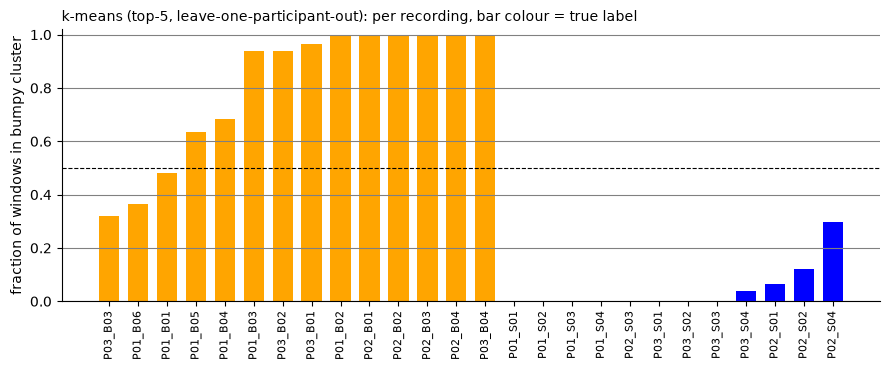

majority vote per recording: 88% of 26 recordings correct


In [190]:
feats = FEATURE_SETS["top-5 Fisher"]
pred = np.zeros(len(df), dtype=int)

for tr, te in SPLITS["leave-one-participant-out"]:
    pred[te.to_numpy()] = kmeans_classifier(tr.to_numpy(), te.to_numpy(), feats)

per_rec = (df.assign(pred_bumpy=pred).groupby("recording_id")
             .agg(label=("label", "first"), frac_bumpy=("pred_bumpy", "mean"), n_windows=("pred_bumpy", "size"))
             .sort_values(["label", "frac_bumpy"]))

fig, ax = plt.subplots(figsize=(9, 3.8))

ax.bar(range(len(per_rec)), per_rec["frac_bumpy"], color=per_rec["label"].map(CLASS_COLOR), width=0.7)
ax.axhline(0.5, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(range(len(per_rec)), per_rec.index, rotation=90, fontsize=8)
ax.set(ylabel="fraction of windows in bumpy cluster", ylim=(0, 1.02))
ax.set_title("k-means (top-5, leave-one-participant-out): per recording, bar colour = true label", loc="left", fontsize=10)
ax.grid(axis="x", visible=False)

fig.tight_layout(); fig.savefig(FIG_DIR / "kmeans_per_recording.png", dpi=120, bbox_inches="tight"); plt.show()
rec_acc = ((per_rec["frac_bumpy"] > 0.5) == (per_rec["label"] == "bumpy")).mean()

print(f"majority vote per recording: {rec_acc:.0%} of {len(per_rec)} recordings correct")

## 3.7 Export results

Classifier model evaluation export for benchmarking/comparison later: 

- `kmeans_metrics_per_fold.csv`: one row per split, model and held-out fold / participant, with confusion counts
- `kmeans_metrics_summary.csv`: mean and worst fold per split and model
- `kmeans_predictions.csv`: out-of-fold prediction for every window, for comparing models later

- **precision**: of the windows predicted bumpy, the fraction that really are bumpy
- **recall**: of the bumpy windows, the fraction found
- **specificity**: of the smooth windows, the fraction correctly called smooth
- **balanced accuracy**: mean of recall and specificity, not affected by class imbalance within a fold

In [191]:
def classification_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    safe = lambda a, b: a / b if b else np.nan
    precision, recall, specificity = safe(tp, tp + fp), safe(tp, tp + fn), safe(tn, tn + fp)
    
    return {"n": len(y_true), "tp": tp, "fp": fp, "tn": tn, "fn": fn,
            "accuracy": (tp + tn) / len(y_true), "balanced_accuracy": (recall + specificity) / 2,
            "precision": precision, "recall": recall, "specificity": specificity,
            "f1": safe(2 * precision * recall, precision + recall)}

FOLD_NAMES = {"grouped folds": [f"fold {k}" for k in range(N_FOLDS)],
              "leave-one-participant-out": sorted(df["participant"].unique())}

metric_rows, pred_frames = [], []
for split_name, splits in SPLITS.items():
    for model_name, predict in MODELS.items():
        for fold_name, (tr, te) in zip(FOLD_NAMES[split_name], splits):
            tr, te = tr.to_numpy(), te.to_numpy()
            yhat = predict(tr, te)
            metric_rows.append({"split": split_name, "model": model_name, "held_out": fold_name,
                                **classification_metrics(y[te], yhat)})
            pred_frames.append(df.loc[te, ["recording_id", "participant", "label"]]
                               .assign(split=split_name, model=model_name, held_out=fold_name,
                                       pred=np.where(yhat == 1, "bumpy", "smooth")))

per_fold = pd.DataFrame(metric_rows)
METRICS = ["accuracy", "balanced_accuracy", "precision", "recall", "specificity", "f1"]
summary = per_fold.groupby(["split", "model"])[METRICS].agg(["mean", "min"])
summary.columns = [f"{m}_{stat}" for m, stat in summary.columns]

per_fold.to_csv(RESULTS_DIR / "kmeans_metrics_per_fold.csv", index=False)
summary.to_csv(RESULTS_DIR / "kmeans_metrics_summary.csv")
pd.concat(pred_frames).rename_axis("window").to_csv(RESULTS_DIR / "kmeans_predictions.csv")
print(f"saved to {RESULTS_DIR.resolve()}")

summary[[f"{m}_mean" for m in METRICS]].round(3)

saved to D:\2-Courses\5ARE0-Project\Machine_Learning_for_rides\artifacts\results


accuracy_mean  \
split                     model                                                      
grouped folds             baseline: threshold on vertbp_madiff               0.940   
                          k-means, 2D: vertbp_madiff + horiz_madiff          0.910   
                          k-means, all kept (52)                             0.834   
                          k-means, top-5 Fisher                              0.915   
leave-one-participant-out baseline: threshold on vertbp_madiff               0.933   
                          k-means, 2D: vertbp_madiff + horiz_madiff          0.906   
                          k-means, all kept (52)                             0.797   
                          k-means, top-5 Fisher                              0.890   

                                                                     balanced_accuracy_mean  \
split                     model                                                               
grouped folds             baseline: threshold on vertbp_madiff                        0.936   
                          k-means, 2D: vertbp_madiff + horiz_madiff                   0.901   
                          k-means, all kept (52)                                      0.815   
                          k-means, top-5 Fisher                                       0.908   
leave-one-participant-out baseline: threshold on vertbp_madiff                        0.938   
                          k-means, 2D: vertbp_madiff + horiz_madiff                   0.915   
                          k-means, all kept (52)                                      0.794   
                          k-means, top-5 Fisher                                       0.901   

                                                                     precision_mean  \
split                     model                                                       
grouped folds             baseline: threshold on vertbp_madiff                0.950   
                          k-means, 2D: vertbp_madiff + horiz_madiff           0.960   
                          k-means, all kept (52)                              0.866   
                          k-means, top-5 Fisher                               0.954   
leave-one-participant-out baseline: threshold on vertbp_madiff                0.946   
                          k-means, 2D: vertbp_madiff + horiz_madiff           0.971   
                          k-means, all kept (52)                              0.868   
                          k-means, top-5 Fisher                               0.955   

                                                                     recall_mean  \
split                     model                                                    
grouped folds             baseline: threshold on vertbp_madiff             0.915   
                          k-means, 2D: vertbp_madiff + horiz_madiff        0.830   
                          k-means, all kept (52)                           0.783   
                          k-means, top-5 Fisher                            0.853   
leave-one-participant-out baseline: threshold on vertbp_madiff             0.929   
                          k-means, 2D: vertbp_madiff + horiz_madiff        0.855   
                          k-means, all kept (52)                           0.751   
                          k-means, top-5 Fisher                            0.844   

                                                                     specificity_mean  \
split                     model                                                         
grouped folds             baseline: threshold on vertbp_madiff                  0.957   
                          k-means, 2D: vertbp_madiff + horiz_madiff             0.971   
                          k-means, all kept (52)                                0.847   
                          k-means, top-5 Fisher                                 0.963   
leave-one-p

**Conclusion:** without ever seeing a label, k-means rediscovers the bumpy/smooth split from vibration amplitude. This supports that the features do capture the road surface rather than the participant only. As a classifier it is not competitive compared to a simple heuristic function 


---
*Copied from `notebooks/decision_tree.ipynb`*

# 4) Decision tree

- Type of model: SUPERVISED
- Model type of approach: self-finding heuristic

In [192]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.model_selection import GroupKFold

PROC_DIR = Path("./artifacts")
FIG_DIR = Path("./figures")
RESULTS_DIR = PROC_DIR / "results"
RESULTS_DIR.mkdir(exist_ok=True)

df = pd.read_csv(PROC_DIR / "features.csv")
sel = json.loads((PROC_DIR / "feature_selection.json").read_text())
y = (df["label"] == "bumpy").to_numpy().astype(int)      # 1 = bumpy, 0 = smooth
N_FOLDS = sel["n_folds"]

print(f"{len(df)} windows, {df['recording_id'].nunique()} recordings, {df['participant'].nunique()} participants")
print(f"{len(sel['kept'])} features kept by the filters, {len(sel['all'])} candidates")

CLASSES = ["bumpy", "smooth"]
CLASS_COLOR = {"bumpy": "orange", "smooth": "blue"}
PALETTE = ["blue", "orange", "green"]

plt.rcParams.update(
    {"axes.grid": True, "grid.color": "gray",
     "axes.spines.top": False, "axes.spines.right": False,
     "lines.linewidth": 1.0, "figure.dpi": 100})

N_FOLDS = sel["n_folds"]
ALL = sel["all"]

# split iterators: lists of (train_mask, test_mask) over windows
SPLITS = {
    "grouped folds": [((df["fold"] != k).to_numpy(), (df["fold"] == k).to_numpy()) for k in range(N_FOLDS)],
    "leave-one-participant-out": [((df["participant"] != p).to_numpy(), (df["participant"] == p).to_numpy())
                                  for p in sorted(df["participant"].unique())],
}

768 windows, 26 recordings, 3 participants
52 features kept by the filters, 66 candidates


## 4.1 A tree on two features

Same two features as in k-means notebook, that were dominant 

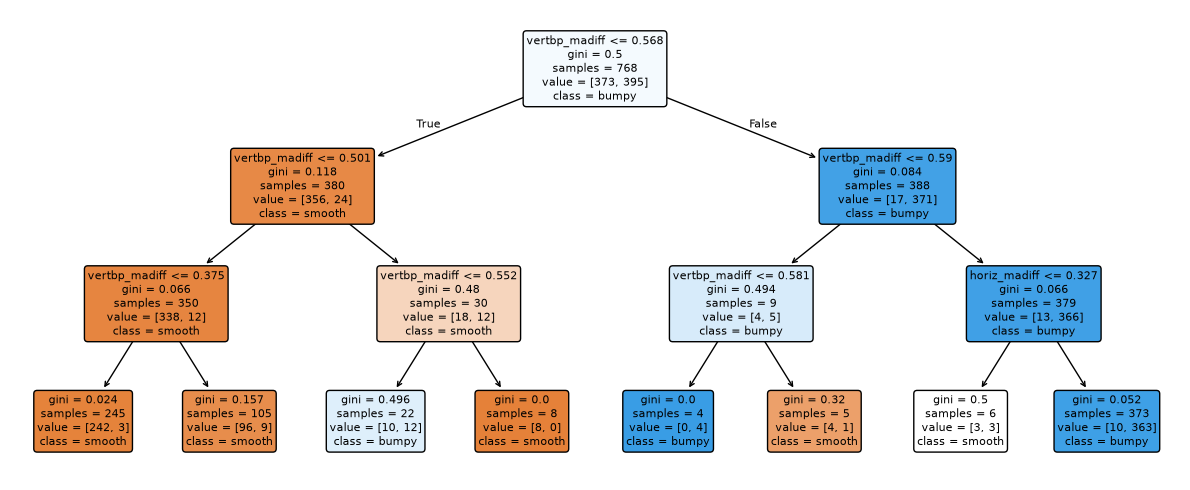

|--- vertbp_madiff <= 0.568
|   |--- vertbp_madiff <= 0.501
|   |   |--- vertbp_madiff <= 0.375
|   |   |   |--- class: smooth
|   |   |--- vertbp_madiff >  0.375
|   |   |   |--- class: smooth
|   |--- vertbp_madiff >  0.501
|   |   |--- vertbp_madiff <= 0.552
|   |   |   |--- class: bumpy
|   |   |--- vertbp_madiff >  0.552
|   |   |   |--- class: smooth
|--- vertbp_madiff >  0.568
|   |--- vertbp_madiff <= 0.590
|   |   |--- vertbp_madiff <= 0.581
|   |   |   |--- class: bumpy
|   |   |--- vertbp_madiff >  0.581
|   |   |   |--- class: smooth
|   |--- vertbp_madiff >  0.590
|   |   |--- horiz_madiff <= 0.327
|   |   |   |--- class: smooth
|   |   |--- horiz_madiff >  0.327
|   |   |   |--- class: bumpy



In [193]:
feats2 = ["vertbp_madiff", "horiz_madiff"]
tree2 = DecisionTreeClassifier(max_depth=3, random_state=0).fit(df[feats2], y)

fig, ax = plt.subplots(figsize=(12, 5))
plot_tree(tree2, feature_names=feats2, class_names=["smooth", "bumpy"], 
          filled=True, rounded=True,
          impurity=True, proportion=False, fontsize=8, ax=ax)

fig.tight_layout(); fig.savefig(FIG_DIR / "tree_2d_rules.png", dpi=120, bbox_inches="tight"); plt.show()

print(export_text(tree2, feature_names=feats2, class_names=["smooth", "bumpy"], decimals=3))

Every split is a horizontal or vertical line, so the decision regions are rectangles. 

Different compared with k-means, whose boundary was one diagonal line between two centroids.

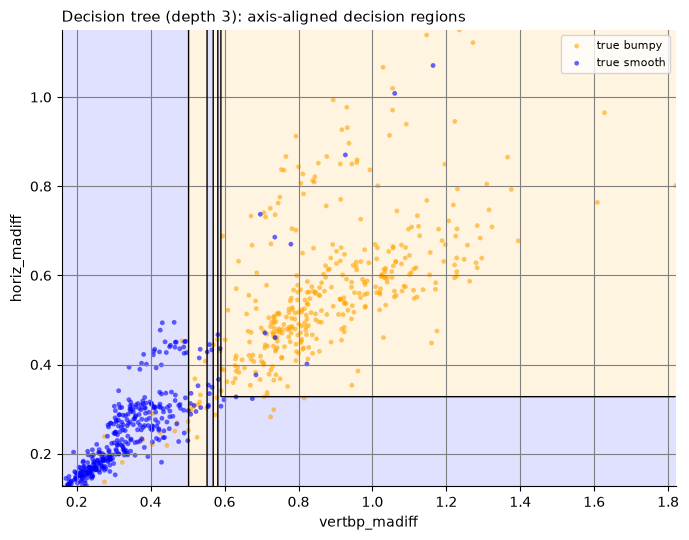

In [194]:
x0, x1 = df[feats2[0]].to_numpy(), df[feats2[1]].to_numpy()
g0, g1 = np.meshgrid(np.linspace(x0.min(), x0.max(), 400), np.linspace(x1.min(), x1.max(), 400))
grid = tree2.predict(pd.DataFrame(np.c_[g0.ravel(), g1.ravel()], columns=feats2)).reshape(g0.shape)

fig, ax = plt.subplots(figsize=(7, 5.5))
ax.contourf(g0, g1, grid, levels=[-0.5, 0.5, 1.5], alpha=0.12, colors=[CLASS_COLOR["smooth"], CLASS_COLOR["bumpy"]])
ax.contour(g0, g1, grid, levels=[0.5], colors="black", linewidths=1)

for lab in CLASSES:
    m = (df["label"] == lab).to_numpy()
    ax.scatter(x0[m], x1[m], s=12, alpha=0.6, color=CLASS_COLOR[lab], edgecolors="none", label=f"true {lab}")
    
ax.set(xlabel=feats2[0], ylabel=feats2[1])
ax.set_title("Decision tree (depth 3): axis-aligned decision regions", loc="left", fontsize=11)
ax.legend(fontsize=8)

fig.tight_layout(); fig.savefig(FIG_DIR / "tree_2d_regions.png", dpi=120, bbox_inches="tight"); plt.show()

## 4.2 Depth vs Accuracy Analysis

The deeper the tree, the more rectangles it can draw. 

Training accuracy always goes up with depth, but on unseen recordings it stops improving (or drops) once the tree starts fitting individual windows. 

This is the bias–variance trade-off in one plot, to find optimal of generalization.

Here the tree gets **all 66 features**. 
`max_depth=None` means the tree is grown until every leaf is pure.

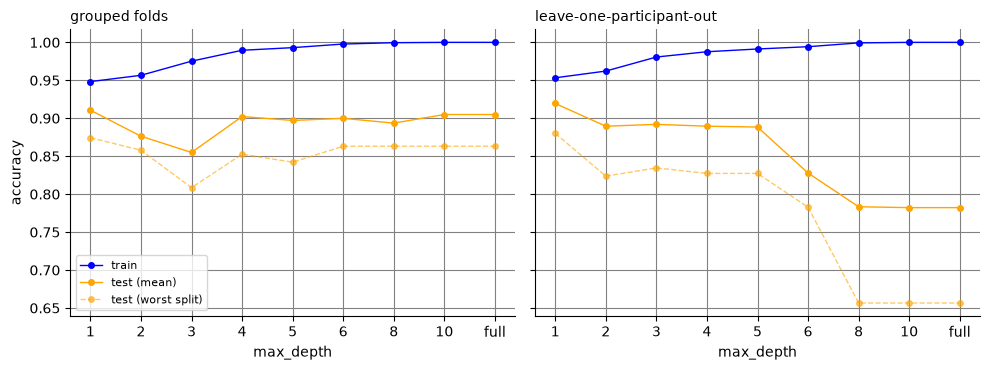

split,grouped folds,leave-one-participant-out
depth,,
1,0.911,0.919
2,0.876,0.890
3,0.855,0.892
4,0.902,0.890
5,0.897,0.888
6,0.900,0.828
8,0.894,0.783
10,0.905,0.782
full,0.905,0.782


In [195]:
DEPTHS = [1, 2, 3, 4, 5, 6, 8, 10, None]

def cv_accuracy(splits, feats, **params):
    tr_acc, te_acc = [], []
    for tr, te in splits:
        clf = DecisionTreeClassifier(random_state=0, **params).fit(df.loc[tr, feats], y[tr])
        tr_acc.append(clf.score(df.loc[tr, feats], y[tr]))
        te_acc.append(clf.score(df.loc[te, feats], y[te]))
        
    return np.mean(tr_acc), np.mean(te_acc), np.min(te_acc)

rows = [{"split": s, "depth": "full" if d is None else d, 
         **dict(zip(["train", "test", "worst test"], cv_accuracy(SPLITS[s], ALL, max_depth=d)))}
        for s in SPLITS for d in DEPTHS]
depth_curve = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
for ax, (s, d) in zip(axes, depth_curve.groupby("split", sort=False)):
    xs = range(len(d))
    ax.plot(xs, d["train"], marker="o", markersize=4, color=PALETTE[0], label="train")
    ax.plot(xs, d["test"], marker="o", markersize=4, color=PALETTE[1], label="test (mean)")
    ax.plot(xs, d["worst test"], marker="o", markersize=4, color=PALETTE[1], linestyle="--", alpha=0.6, label="test (worst split)")
    ax.set_xticks(xs, d["depth"]); ax.set(xlabel="max_depth")
    ax.set_title(s, loc="left", fontsize=10)
    
axes[0].set_ylabel("accuracy"); axes[0].legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG_DIR / "tree_depth_curve.png", dpi=120, bbox_inches="tight"); plt.show()

depth_curve.pivot(index="depth", columns="split", values="test").reindex(["full" if d is None else d for d in DEPTHS]).round(3)

## 4.3 Decision Tree feature break-down

Earlier we have explored by Fisher score the ranking, but here the decision tree choose itself the optimal features based on the training.

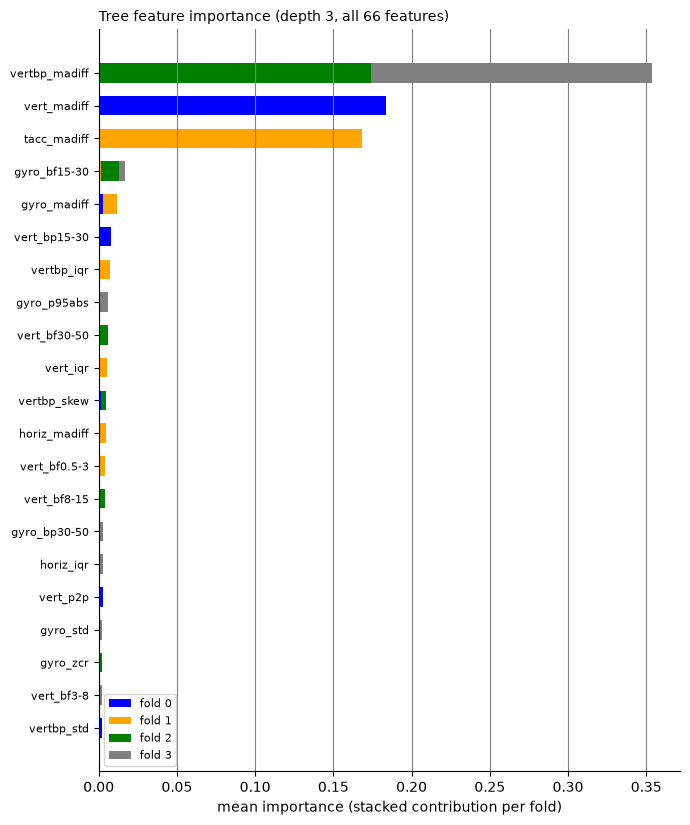

,fold 0,fold 1,fold 2,fold 3,mean,folds used,Fisher rank
vertbp_madiff,0.000,0.000,0.870,0.899,0.442,2,1
vert_madiff,0.918,0.000,0.000,0.000,0.229,1,removed by filter
tacc_madiff,0.000,0.842,0.000,0.000,0.211,1,removed by filter
gyro_bf15-30,0.000,0.007,0.057,0.021,0.021,3,25
gyro_madiff,0.013,0.045,0.000,0.000,0.014,2,23
vert_bp15-30,0.040,0.000,0.000,0.000,0.010,1,16
vertbp_iqr,0.000,0.037,0.000,0.000,0.009,1,2
gyro_p95abs,0.000,0.000,0.000,0.031,0.008,1,48
vert_bf30-50,0.000,0.000,0.029,0.000,0.007,1,50
vert_iqr,0.000,0.026,0.000,0.000,0.007,1,10


In [196]:
DEPTH_SHOW = 3

imp = pd.DataFrame({f"fold {k}": 
    DecisionTreeClassifier(max_depth=DEPTH_SHOW, random_state=0).fit(df.loc[tr, ALL], y[tr]).feature_importances_
                    for k, (tr, _) in enumerate(SPLITS["grouped folds"])}, index=ALL)

imp = imp.loc[(imp > 0).any(axis=1)]
imp["mean"] = imp.mean(axis=1)
imp["folds used"] = (imp.drop(columns="mean") > 0).sum(axis=1)
imp["Fisher rank"] = [sel["ranked_by_fisher"].index(f) + 1 if f in sel["ranked_by_fisher"] else "removed by filter" for f in imp.index]
imp = imp.sort_values("mean", ascending=False)

fig, ax = plt.subplots(figsize=(7, 0.35 * len(imp) + 1))
fold_cols = [c for c in imp.columns if c.startswith("fold")]
left = np.zeros(len(imp))

for c, color in zip(fold_cols, ["blue", "orange", "green", "gray"]):
    ax.barh(range(len(imp))[::-1], imp[c] / len(fold_cols), left=left, color=color, height=0.6, label=c)
    left += imp[c].to_numpy() / len(fold_cols)
    
ax.set_yticks(range(len(imp))[::-1], imp.index, fontsize=8)
ax.set_xlabel("mean importance (stacked contribution per fold)")
ax.set_title(f"Tree feature importance (depth {DEPTH_SHOW}, all {len(ALL)} features)", loc="left", fontsize=10)
ax.grid(axis="y", visible=False); ax.legend(fontsize=8)

fig.tight_layout(); fig.savefig(FIG_DIR / "tree_importance.png", dpi=120, bbox_inches="tight"); plt.show()

imp.round(3)

## 4.4 Cross-validation

Nested CV:

- **outer loop**: leave one participant out, this participant is only used for the final score
- **inner loop**: on the remaining two participants, a grouped CV (by recording) picks `max_depth`
- the tree is then refitted on all outer-training data with the chosen depth

Compared against:
- a **depth-1 tree** ("stump"): one feature, one threshold. The tree picks the feature and threshold itself, so this is the learned version of the single-feature baseline.
- **Threshold on `vertbp_madiff`** as a sanity check

In [197]:
INNER_DEPTHS = [1, 2, 3, 4, 5, 6, 8, None]

def nested_tree(tr, te, feats):
    inner = GroupKFold(n_splits=4).split(df.loc[tr, feats], y[tr], groups=df.loc[tr, "recording_id"])
    inner = [(np.isin(np.arange(len(df)), np.flatnonzero(tr)[a]), np.isin(np.arange(len(df)), np.flatnonzero(tr)[b])) for a, b in inner]
    best = max(INNER_DEPTHS, key=lambda d: cv_accuracy(inner, feats, max_depth=d)[1])
    clf = DecisionTreeClassifier(max_depth=best, random_state=0).fit(df.loc[tr, feats], y[tr])
    return clf.predict(df.loc[te, feats]), best

def stump(tr, te, feats):
    return DecisionTreeClassifier(max_depth=1, random_state=0).fit(df.loc[tr, feats], y[tr]).predict(df.loc[te, feats])

def full_tree(tr, te, feats):
    return DecisionTreeClassifier(random_state=0).fit(df.loc[tr, feats], y[tr]).predict(df.loc[te, feats])

def threshold_baseline(tr, te, f="vertbp_madiff"):
    x = df[f].to_numpy()
    thr = (np.median(x[tr][y[tr] == 1]) + np.median(x[tr][y[tr] == 0])) / 2
    return (x[te] > thr).astype(int)

rows, chosen = [], {}
for p, (tr, te) in zip(sorted(df["participant"].unique()), SPLITS["leave-one-participant-out"]):
    pred, best = nested_tree(tr, te, ALL)
    chosen[p] = "full" if best is None else best
    for model, yhat in {"tree, depth by inner CV": pred, "stump (depth 1)": stump(tr, te, ALL),
                        "full-depth tree": full_tree(tr, te, ALL), "baseline: threshold on vertbp_madiff": threshold_baseline(tr, te)}.items():
        rows.append({"model": model, "held-out participant": p, "accuracy": (yhat == y[te]).mean()})

nested = pd.DataFrame(rows).pivot(index="model", columns="held-out participant", values="accuracy")
nested["mean"] = nested.mean(axis=1)

print("depth chosen by the inner CV per held-out participant:", chosen)
nested.sort_values("mean", ascending=False).round(3)

depth chosen by the inner CV per held-out participant: {'P01': 1, 'P02': 1, 'P03': 1}


held-out participant,P01,P02,P03,mean
model,,,,
baseline: threshold on vertbp_madiff,0.949,0.928,0.921,0.933
stump (depth 1),0.965,0.880,0.914,0.919
"tree, depth by inner CV",0.965,0.880,0.914,0.919
full-depth tree,0.657,0.866,0.824,0.782


## 4.5 Macro Evaluation: Per recording

For every recording, the fraction of its windows predicted *bumpy* by the nested-CV tree when that recording's participant was held out.

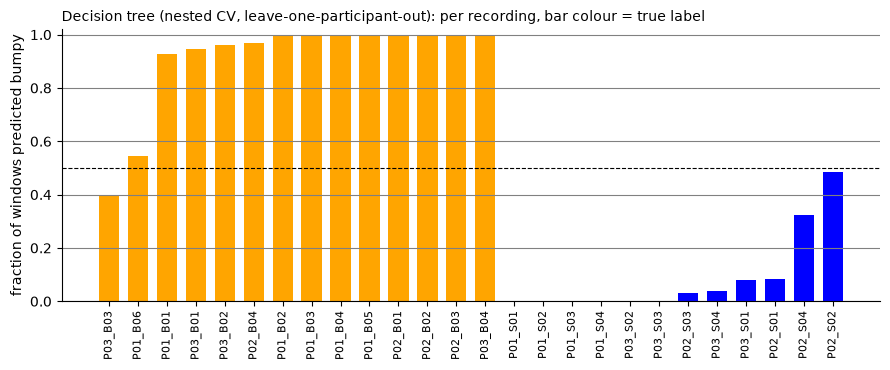

majority vote per recording: 96% of 26 recordings correct


In [198]:
pred = np.zeros(len(df), dtype=int)
for tr, te in SPLITS["leave-one-participant-out"]:
    pred[te] = nested_tree(tr, te, ALL)[0]

per_rec = (df.assign(pred_bumpy=pred).groupby("recording_id")
             .agg(label=("label", "first"), frac_bumpy=("pred_bumpy", "mean"), n_windows=("pred_bumpy", "size"))
             .sort_values(["label", "frac_bumpy"]))

fig, ax = plt.subplots(figsize=(9, 3.8))

ax.bar(range(len(per_rec)), per_rec["frac_bumpy"], color=per_rec["label"].map(CLASS_COLOR), width=0.7)
ax.axhline(0.5, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(range(len(per_rec)), per_rec.index, rotation=90, fontsize=8)
ax.set(ylabel="fraction of windows predicted bumpy", ylim=(0, 1.02))
ax.set_title("Decision tree (nested CV, leave-one-participant-out): per recording, bar colour = true label", loc="left", fontsize=10)
ax.grid(axis="x", visible=False)

fig.tight_layout(); fig.savefig(FIG_DIR / "tree_per_recording.png", dpi=120, bbox_inches="tight"); plt.show()

rec_acc = ((per_rec["frac_bumpy"] > 0.5) == (per_rec["label"] == "bumpy")).mean()
print(f"majority vote per recording: {rec_acc:.0%} of {len(per_rec)} recordings correct")

## 4.6 Export results

Same format as the k-means export, so the files can be concatenated into one comparison table. Saved to `artifacts/results/`:

- `tree_metrics_per_fold.csv`: one row per split, model and held-out fold / participant, with confusion counts
- `tree_metrics_summary.csv`: mean and worst fold per split and model
- `tree_predictions.csv`: out-of-fold prediction for every window

- **precision**: of the windows predicted bumpy, the fraction that really are bumpy
- **recall**: of the bumpy windows, the fraction found
- **specificity**: of the smooth windows, the fraction correctly called smooth
- **balanced accuracy**: mean of recall and specificity, not affected by class imbalance within a fold

In [199]:
from sklearn.metrics import confusion_matrix

def classification_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    safe = lambda a, b: a / b if b else np.nan
    precision, recall, specificity = safe(tp, tp + fp), safe(tp, tp + fn), safe(tn, tn + fp)
    
    return {"n": len(y_true), "tp": tp, "fp": fp, "tn": tn, "fn": fn,
            "accuracy": (tp + tn) / len(y_true), "balanced_accuracy": (recall + specificity) / 2,
            "precision": precision, "recall": recall, "specificity": specificity,
            "f1": safe(2 * precision * recall, precision + recall)}

MODELS = {
    "tree, depth by inner CV": lambda tr, te: nested_tree(tr, te, ALL)[0],
    "stump (depth 1)": lambda tr, te: stump(tr, te, ALL),
    "full-depth tree": lambda tr, te: full_tree(tr, te, ALL),
    "baseline: threshold on vertbp_madiff": threshold_baseline,
}

FOLD_NAMES = {"grouped folds": [f"fold {k}" for k in range(N_FOLDS)],
              "leave-one-participant-out": sorted(df["participant"].unique())}

metric_rows, pred_frames = [], []
for split_name, splits in SPLITS.items():
    for model_name, predict in MODELS.items():
        for fold_name, (tr, te) in zip(FOLD_NAMES[split_name], splits):
            yhat = predict(tr, te)
            metric_rows.append({"split": split_name, "model": model_name, "held_out": fold_name,
                                **classification_metrics(y[te], yhat)})
            pred_frames.append(df.loc[te, ["recording_id", "participant", "label"]]
                               .assign(split=split_name, model=model_name, held_out=fold_name,
                                       pred=np.where(yhat == 1, "bumpy", "smooth")))

per_fold = pd.DataFrame(metric_rows)
METRICS = ["accuracy", "balanced_accuracy", "precision", "recall", "specificity", "f1"]
summary = per_fold.groupby(["split", "model"])[METRICS].agg(["mean", "min"])
summary.columns = [f"{m}_{stat}" for m, stat in summary.columns]

per_fold.to_csv(RESULTS_DIR / "tree_metrics_per_fold.csv", index=False)
summary.to_csv(RESULTS_DIR / "tree_metrics_summary.csv")
pd.concat(pred_frames).rename_axis("window").to_csv(RESULTS_DIR / "tree_predictions.csv")
print(f"saved to {RESULTS_DIR.resolve()}")

summary[[f"{m}_mean" for m in METRICS]].round(3)

saved to D:\2-Courses\5ARE0-Project\Machine_Learning_for_rides\artifacts\results


accuracy_mean  \
split                     model                                                 
grouped folds             baseline: threshold on vertbp_madiff          0.940   
                          full-depth tree                               0.905   
                          stump (depth 1)                               0.911   
                          tree, depth by inner CV                       0.888   
leave-one-participant-out baseline: threshold on vertbp_madiff          0.933   
                          full-depth tree                               0.782   
                          stump (depth 1)                               0.919   
                          tree, depth by inner CV                       0.919   

                                                                balanced_accuracy_mean  \
split                     model                                                          
grouped folds             baseline: threshold on vertbp_madiff                   0.936   
                          full-depth tree                                        0.905   
                          stump (depth 1)                                        0.903   
                          tree, depth by inner CV                                0.879   
leave-one-participant-out baseline: threshold on vertbp_madiff                   0.938   
                          full-depth tree                                        0.804   
                          stump (depth 1)                                        0.927   
                          tree, depth by inner CV                                0.927   

                                                                precision_mean  \
split                     model                                                  
grouped folds             baseline: threshold on vertbp_madiff           0.950   
                          full-depth tree                                0.902   
                          stump (depth 1)                                0.895   
                          tree, depth by inner CV                        0.870   
leave-one-participant-out baseline: threshold on vertbp_madiff           0.946   
                          full-depth tree                                0.917   
                          stump (depth 1)                                0.921   
                          tree, depth by inner CV                        0.921   

                                                                recall_mean  \
split                     model                                               
grouped folds             baseline: threshold on vertbp_madiff        0.915   
                          full-depth tree                             0.906   
                          stump (depth 1)                             0.935   
                          tree, depth by inner CV                     0.922   
leave-one-participant-out baseline: threshold on vertbp_madiff        0.929   
                          full-depth tree                             0.694   
                          stump (depth 1)                             0.933   
                          tree, depth by inner CV                     0.933   

                                                                specificity_mean  \
split                     model                                                    
grouped folds             baseline: threshold on vertbp_madiff             0.957   
                          full-depth tree                                  0.904   
                          stump (depth 1)                                  0.872   
                          tree, depth by inner CV                          0.836   
leave-one-participant-out baseline: threshold on vertbp_madiff             0.948   
                          full-depth tree                                  0.915   
                          stump (depth 1)                           

---
*Copied from `notebooks/random_forest.ipynb`*

# 5) Random forest

- Type of model: SUPERVISED
- Model type of approach: ensemble of self-finding heuristics (bagging of decision trees)


In [200]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GroupKFold

PROC_DIR = Path("./artifacts")
FIG_DIR = Path("./figures")
RESULTS_DIR = PROC_DIR / "results"
RESULTS_DIR.mkdir(exist_ok=True)

df = pd.read_csv(PROC_DIR / "features.csv")
sel = json.loads((PROC_DIR / "feature_selection.json").read_text())
y = (df["label"] == "bumpy").to_numpy().astype(int)      # 1 = bumpy, 0 = smooth

print(f"{len(df)} windows, {df['recording_id'].nunique()} recordings, {df['participant'].nunique()} participants")
print(f"{len(sel['kept'])} features kept by the filters, {len(sel['all'])} candidates")

CLASSES = ["bumpy", "smooth"]
CLASS_COLOR = {"bumpy": "orange", "smooth": "blue"}
PALETTE = ["blue", "orange", "green"]

plt.rcParams.update(
    {"axes.grid": True, "grid.color": "gray",
     "axes.spines.top": False, "axes.spines.right": False,
     "lines.linewidth": 1.0, "figure.dpi": 100})


768 windows, 26 recordings, 3 participants
52 features kept by the filters, 66 candidates


## 5.1 Hyperparams Random Forest

In [201]:
N_FOLDS = sel["n_folds"]
ALL = sel["all"]
N_TREES = 200
DEPTH = 3

# split iterators: lists of (train_mask, test_mask) over windows
SPLITS = {
    "grouped folds": [((df["fold"] != k).to_numpy(), (df["fold"] == k).to_numpy()) for k in range(N_FOLDS)],
    "leave-one-participant-out": [((df["participant"] != p).to_numpy(), (df["participant"] == p).to_numpy())
                                  for p in sorted(df["participant"].unique())],
}

## 5.2 Forest Feature selection

Same two features as for k-means and decision tree.  

Every tree still draws axis-aligned rectangles, but each tree sees a different bootstrap sample, so the thresholds differ slightly per tree.

The background shows the forest's **predicted probability of bumpy** (fraction of trees voting bumpy): The black line is the 0.5 decision boundary. 

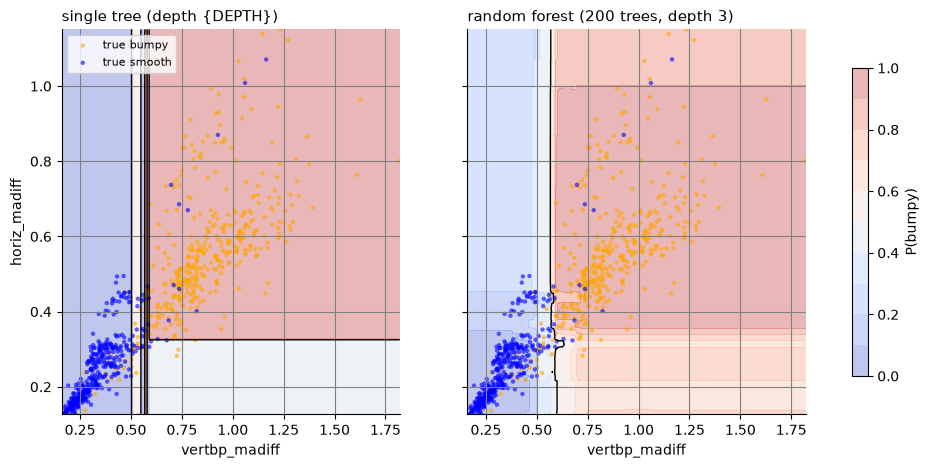

In [202]:
def forest(**params):
    return RandomForestClassifier(n_estimators=params.pop("n_estimators", N_TREES), random_state=0, n_jobs=-1, **params)

feats2 = ["vertbp_madiff", "horiz_madiff"]
tree2 = DecisionTreeClassifier(max_depth=DEPTH, random_state=0).fit(df[feats2], y)
rf2 = forest(max_depth=DEPTH).fit(df[feats2], y)

x0, x1 = df[feats2[0]].to_numpy(), df[feats2[1]].to_numpy()
g0, g1 = np.meshgrid(np.linspace(x0.min(), x0.max(), 300), np.linspace(x1.min(), x1.max(), 300))
G = pd.DataFrame(np.c_[g0.ravel(), g1.ravel()], columns=feats2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, (name, model) in zip(axes, {"single tree (depth {DEPTH})": tree2, f"random forest ({N_TREES} trees, depth {DEPTH})": rf2}.items()):
    
    proba = model.predict_proba(G)[:, 1].reshape(g0.shape)
    cf = ax.contourf(g0, g1, proba, levels=np.linspace(0, 1, 11), cmap="coolwarm", alpha=0.35)
    ax.contour(g0, g1, proba, levels=[0.5], colors="black", linewidths=1)
    
    for lab in CLASSES:
        m = (df["label"] == lab).to_numpy()
        ax.scatter(x0[m], x1[m], s=10, alpha=0.6, color=CLASS_COLOR[lab], edgecolors="none", label=f"true {lab}")
        
    ax.set(xlabel=feats2[0])
    ax.set_title(name, loc="left", fontsize=11)

axes[0].set_ylabel(feats2[1]); axes[0].legend(fontsize=8)

fig.colorbar(cf, ax=axes, label="P(bumpy)", shrink=0.8)
fig.savefig(FIG_DIR / "rf_2d_regions.png", dpi=120, bbox_inches="tight"); plt.show()

## 5.3 Depth vs Accuracy Analysis: forest versus single tree

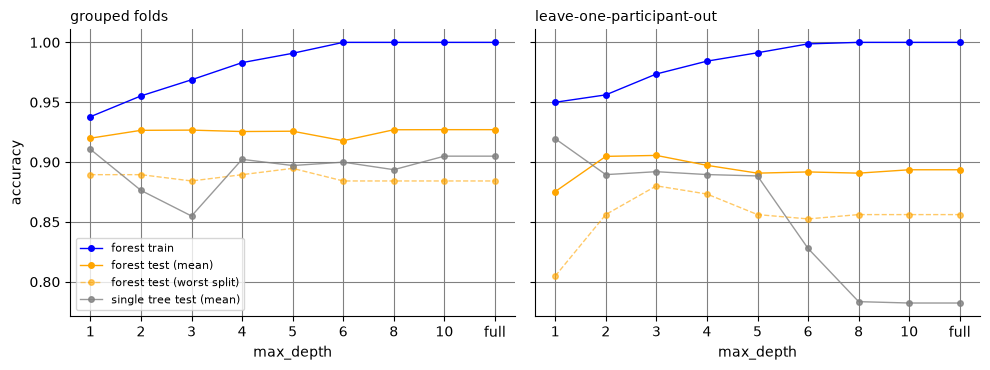

split grouped folds             leave-one-participant-out            
model        forest single tree                    forest single tree
depth                                                                
1             0.920       0.911                     0.875       0.919
2             0.927       0.876                     0.905       0.890
3             0.927       0.855                     0.906       0.892
4             0.926       0.902                     0.897       0.890
5             0.926       0.897                     0.891       0.888
6             0.918       0.900                     0.892       0.828
8             0.927       0.894                     0.891       0.783
10            0.927       0.905                     0.894       0.782
full          0.927       0.905                     0.894       0.782

In [203]:
DEPTHS = [1, 2, 3, 4, 5, 6, 8, 10, None]

def cv_accuracy(splits, feats, make):
    tr_acc, te_acc = [], []
    for tr, te in splits:
        clf = make().fit(df.loc[tr, feats], y[tr])
        tr_acc.append(clf.score(df.loc[tr, feats], y[tr]))
        te_acc.append(clf.score(df.loc[te, feats], y[te]))

    return np.mean(tr_acc), np.mean(te_acc), np.min(te_acc)

MAKERS = {"forest": lambda d: forest(max_depth=d),
          "single tree": lambda d: DecisionTreeClassifier(max_depth=d, random_state=0)}

rows = [{"split": s, "model": m, "depth": "full" if d is None else d,
         **dict(zip(["train", "test", "worst test"], cv_accuracy(SPLITS[s], ALL, lambda: make(d))))}
        for s in SPLITS for m, make in MAKERS.items() for d in DEPTHS]

depth_curve = pd.DataFrame(rows)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), sharey=True)
for ax, (s, d) in zip(axes, depth_curve.groupby("split", sort=False)):
    xs = range(len(DEPTHS))
    
    f, t = d[d["model"] == "forest"], d[d["model"] == "single tree"]
    ax.plot(xs, f["train"], marker="o", markersize=4, color=PALETTE[0], label="forest train")
    ax.plot(xs, f["test"], marker="o", markersize=4, color=PALETTE[1], label="forest test (mean)")
    ax.plot(xs, f["worst test"], marker="o", markersize=4, color=PALETTE[1], linestyle="--", alpha=0.6, label="forest test (worst split)")
    ax.plot(xs, t["test"], marker="o", markersize=4, color="gray", alpha=0.8, label="single tree test (mean)")
    ax.set_xticks(xs, f["depth"]); ax.set(xlabel="max_depth")
    ax.set_title(s, loc="left", fontsize=10)

axes[0].set_ylabel("accuracy"); axes[0].legend(fontsize=8)
fig.tight_layout(); fig.savefig(FIG_DIR / "rf_depth_curve.png", dpi=120, bbox_inches="tight"); plt.show()

depth_curve.pivot_table(index="depth", columns=["split", "model"], values="test", sort=False).round(3)

## 5.3 Number of trees and out-of-bag error

More trees never make a random forest overfit more, the vote only gets more stable. The question is how many are needed before the accuracy stops changing.

Each tree leaves out about a third of the windows from its bootstrap sample. Predicting those **out-of-bag (OOB)** windows gives a free internal validation score. But the windows of one recording are strongly correlated, so a window's neighbours are almost always in the bag: the OOB score is **optimistic** compared with testing on an unseen participant.

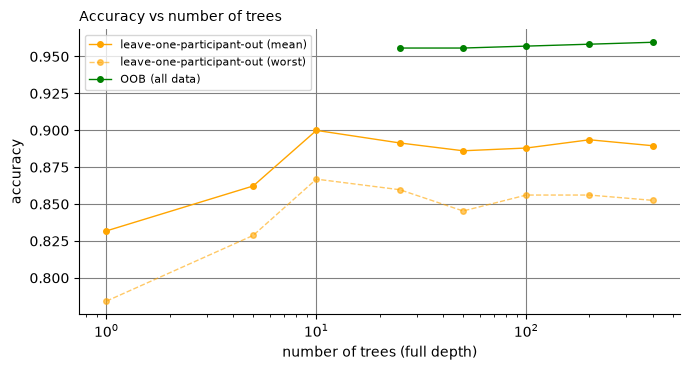

,leave-one-participant-out (mean),leave-one-participant-out (worst),OOB (all data)
n_trees,,,
1,0.832,0.784,NaN
5,0.862,0.829,NaN
10,0.900,0.867,NaN
25,0.891,0.860,0.956
50,0.886,0.845,0.956
100,0.888,0.856,0.957
200,0.894,0.856,0.958
400,0.890,0.853,0.960


In [204]:
N_GRID = [1, 5, 10, 25, 50, 100, 200, 400]

rows = []
for n in N_GRID:
    lopo = [forest(n_estimators=n).fit(df.loc[tr, ALL], y[tr]).score(df.loc[te, ALL], y[te])
            for tr, te in SPLITS["leave-one-participant-out"]]
    oob = forest(n_estimators=n, oob_score=True, bootstrap=True).fit(df[ALL], y).oob_score_ if n >= 25 else np.nan
    rows.append({"n_trees": n, "leave-one-participant-out (mean)": np.mean(lopo),
                 "leave-one-participant-out (worst)": np.min(lopo), "OOB (all data)": oob})
ntree_curve = pd.DataFrame(rows).set_index("n_trees")

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.plot(ntree_curve.index, ntree_curve.iloc[:, 0], marker="o", markersize=4, color=PALETTE[1], label=ntree_curve.columns[0])
ax.plot(ntree_curve.index, ntree_curve.iloc[:, 1], marker="o", markersize=4, color=PALETTE[1], linestyle="--", alpha=0.6, label=ntree_curve.columns[1])
ax.plot(ntree_curve.index, ntree_curve.iloc[:, 2], marker="o", markersize=4, color=PALETTE[2], label=ntree_curve.columns[2])
ax.set_xscale("log"); ax.set(xlabel="number of trees (full depth)", ylabel="accuracy")
ax.set_title("Accuracy vs number of trees", loc="left", fontsize=10); ax.legend(fontsize=8)

fig.tight_layout(); fig.savefig(FIG_DIR / "rf_ntrees_curve.png", dpi=120, bbox_inches="tight"); plt.show()

ntree_curve.round(3)

## 5.4 Random forest feature break-down

The single tree used only a handful of features, and which one it picked changed per fold. The forest spreads the importance over all features that carry information, because at each split only a random subset (`max_features="sqrt"`, 8 of 66) is available.

Impurity-based importance, averaged over the trees and shown stacked per grouped fold. Top 20 features.

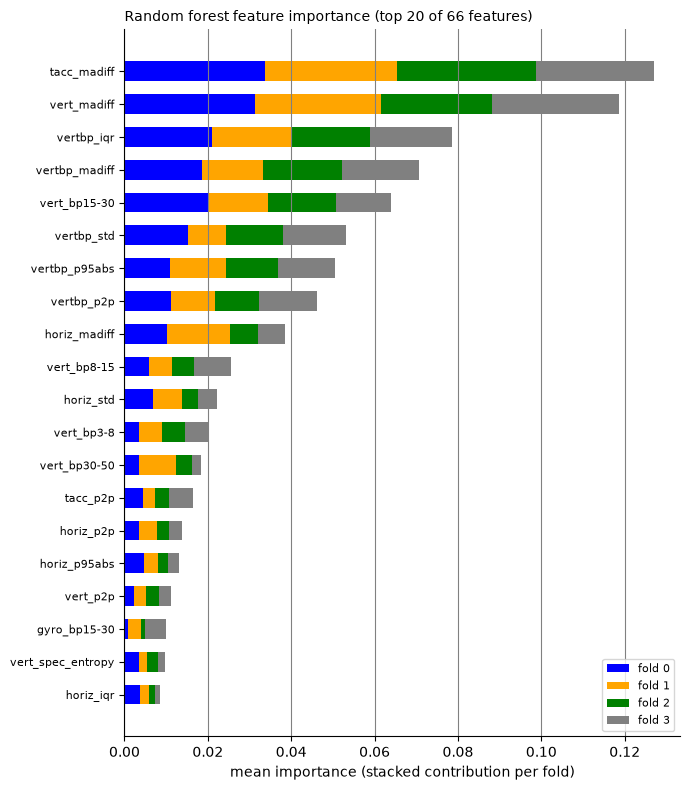

,fold 0,fold 1,fold 2,fold 3,mean,Fisher rank
tacc_madiff,0.135,0.127,0.134,0.112,0.127,removed by filter
vert_madiff,0.125,0.121,0.106,0.122,0.119,removed by filter
vertbp_iqr,0.084,0.077,0.074,0.079,0.079,2
vertbp_madiff,0.074,0.059,0.075,0.074,0.071,1
vert_bp15-30,0.080,0.057,0.066,0.053,0.064,16
vertbp_std,0.061,0.037,0.055,0.060,0.053,removed by filter
vertbp_p95abs,0.044,0.054,0.050,0.054,0.050,3
vertbp_p2p,0.044,0.043,0.042,0.055,0.046,5
horiz_madiff,0.041,0.061,0.027,0.026,0.038,4
vert_bp8-15,0.024,0.022,0.020,0.036,0.026,9


In [205]:
TOP = 20

imp = pd.DataFrame({f"fold {k}": forest().fit(df.loc[tr, ALL], y[tr]).feature_importances_
                    for k, (tr, _) in enumerate(SPLITS["grouped folds"])}, index=ALL)

imp["mean"] = imp.mean(axis=1)
imp["Fisher rank"] = [sel["ranked_by_fisher"].index(f) + 1 if f in sel["ranked_by_fisher"] else "removed by filter" for f in imp.index]
imp = imp.sort_values("mean", ascending=False).head(TOP)

fig, ax = plt.subplots(figsize=(7, 0.35 * len(imp) + 1))
fold_cols = [c for c in imp.columns if c.startswith("fold")]
left = np.zeros(len(imp))

for c, color in zip(fold_cols, ["blue", "orange", "green", "gray"]):
    ax.barh(range(len(imp))[::-1], imp[c] / len(fold_cols), left=left, color=color, height=0.6, label=c)
    left += imp[c].to_numpy() / len(fold_cols)

ax.set_yticks(range(len(imp))[::-1], imp.index, fontsize=8)
ax.set_xlabel("mean importance (stacked contribution per fold)")
ax.set_title(f"Random forest feature importance (top {TOP} of {len(ALL)} features)", loc="left", fontsize=10)
ax.grid(axis="y", visible=False); ax.legend(fontsize=8)

fig.tight_layout(); fig.savefig(FIG_DIR / "rf_importance.png", dpi=120, bbox_inches="tight"); plt.show()

imp.round(3)

## 5.5 Cross-validation

Nested CV, same as for the decision tree:

- **outer loop**: leave one participant out, this participant is only used for the final score
- **inner loop**: on the remaining two participants, a grouped CV (by recording) picks `max_depth` and `max_features`
- the forest is then refitted on all outer-training data with the chosen hyperparameters

Compared against:
- a **default forest** (full depth, `max_features="sqrt"`), no tuning
- the **full-depth single tree** and the **stump** from notebook 4
- **Threshold on `vertbp_madiff`** as a sanity check

In [206]:
INNER_GRID = [{"max_depth": d, "max_features": f} for d in [2, 3, 5, 8, None] for f in ["sqrt", 0.3]]

def inner_splits(tr):
    idx = np.flatnonzero(tr)
    inner = GroupKFold(n_splits=4).split(idx, groups=df.loc[tr, "recording_id"])
    return [(np.isin(np.arange(len(df)), idx[a]), np.isin(np.arange(len(df)), idx[b])) for a, b in inner]

def nested_forest(tr, te, feats):
    inner = inner_splits(tr)
    best = max(INNER_GRID, key=lambda p: cv_accuracy(inner, feats, lambda: forest(**p))[1])
    clf = forest(**best).fit(df.loc[tr, feats], y[tr])
    return clf.predict(df.loc[te, feats]), best

def default_forest(tr, te, feats):
    return forest().fit(df.loc[tr, feats], y[tr]).predict(df.loc[te, feats])

def stump(tr, te, feats):
    return DecisionTreeClassifier(max_depth=1, random_state=0).fit(df.loc[tr, feats], y[tr]).predict(df.loc[te, feats])

def full_tree(tr, te, feats):
    return DecisionTreeClassifier(random_state=0).fit(df.loc[tr, feats], y[tr]).predict(df.loc[te, feats])

def threshold_baseline(tr, te, f="vertbp_madiff"):
    x = df[f].to_numpy()
    thr = (np.median(x[tr][y[tr] == 1]) + np.median(x[tr][y[tr] == 0])) / 2
    return (x[te] > thr).astype(int)

# nested CV is the slow part: cache its out-of-fold predictions for 5.6 and 5.7
nested_pred = {s: {} for s in SPLITS}

rows, chosen = [], {}
for p, (tr, te) in zip(sorted(df["participant"].unique()), SPLITS["leave-one-participant-out"]):
    pred, best = nested_forest(tr, te, ALL)
    nested_pred["leave-one-participant-out"][p] = pred
    chosen[p] = best
    
    for model, yhat in {"forest, tuned by inner CV": pred, "default forest": default_forest(tr, te, ALL),
                        "full-depth tree": full_tree(tr, te, ALL), "stump (depth 1)": stump(tr, te, ALL),
                        "baseline: threshold on vertbp_madiff": threshold_baseline(tr, te)}.items():
        rows.append({"model": model, "held-out participant": p, "accuracy": (yhat == y[te]).mean()})

nested = pd.DataFrame(rows).pivot(index="model", columns="held-out participant", values="accuracy")
nested["mean"] = nested.mean(axis=1)

print("hyperparameters chosen by the inner CV per held-out participant:")

for p, b in chosen.items():
    print(f"  {p}: {b}")
    
nested.sort_values("mean", ascending=False).round(3)

hyperparameters chosen by the inner CV per held-out participant:
  P01: {'max_depth': 2, 'max_features': 'sqrt'}
  P02: {'max_depth': 2, 'max_features': 'sqrt'}
  P03: {'max_depth': 8, 'max_features': 'sqrt'}


held-out participant,P01,P02,P03,mean
model,,,,
baseline: threshold on vertbp_madiff,0.949,0.928,0.921,0.933
stump (depth 1),0.965,0.880,0.914,0.919
default forest,0.944,0.880,0.856,0.894
"forest, tuned by inner CV",0.944,0.856,0.856,0.886
full-depth tree,0.657,0.866,0.824,0.782


**Takeaway**

- Averaging fixes the overfitting of the single tree: the full-depth forest scores 0.89 on an unseen participant, compared with 0.78 for the full-depth tree, and its accuracy stays flat as depth grows (5.2).
- It still does not beat the stump or the threshold on `vertbp_madiff`. The bumpy/smooth split is essentially one-dimensional, so the extra features mostly add participant-specific variation that does not transfer.
- Tuning in the inner CV does not help (0.886 vs 0.894 for the default forest). With only two training participants, the inner folds are too noisy to pick hyperparameters reliably.
- The OOB score (~0.96) is clearly optimistic compared with leave-one-participant-out (~0.89), because windows from the same recording are correlated.

## 5.6 Macro Evaluation: Per recording

For every recording, the fraction of its windows predicted *bumpy* by the nested-CV forest when that recording's participant was held out.

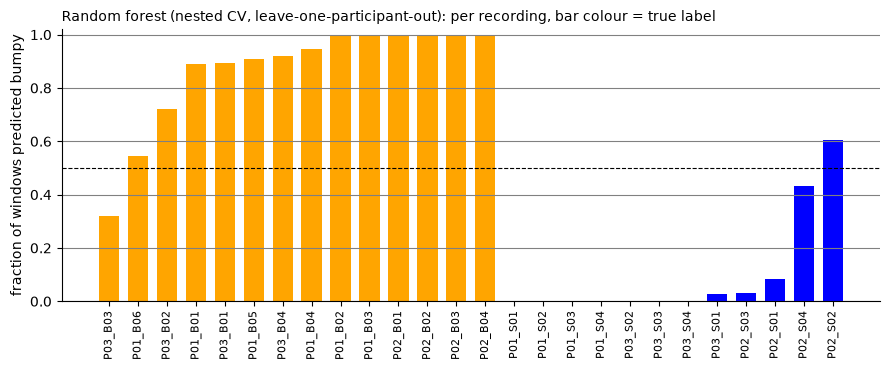

majority vote per recording: 92% of 26 recordings correct


In [207]:
pred = np.zeros(len(df), dtype=int)

for p, (tr, te) in zip(sorted(df["participant"].unique()), SPLITS["leave-one-participant-out"]):
    pred[te] = nested_pred["leave-one-participant-out"][p]

per_rec = (df.assign(pred_bumpy=pred).groupby("recording_id")
             .agg(label=("label", "first"), frac_bumpy=("pred_bumpy", "mean"), n_windows=("pred_bumpy", "size"))
             .sort_values(["label", "frac_bumpy"]))

fig, ax = plt.subplots(figsize=(9, 3.8))

ax.bar(range(len(per_rec)), per_rec["frac_bumpy"], color=per_rec["label"].map(CLASS_COLOR), width=0.7)
ax.axhline(0.5, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(range(len(per_rec)), per_rec.index, rotation=90, fontsize=8)
ax.set(ylabel="fraction of windows predicted bumpy", ylim=(0, 1.02))
ax.set_title("Random forest (nested CV, leave-one-participant-out): per recording, bar colour = true label", loc="left", fontsize=10)
ax.grid(axis="x", visible=False)

fig.tight_layout(); fig.savefig(FIG_DIR / "rf_per_recording.png", dpi=120, bbox_inches="tight"); plt.show()

rec_acc = ((per_rec["frac_bumpy"] > 0.5) == (per_rec["label"] == "bumpy")).mean()
print(f"majority vote per recording: {rec_acc:.0%} of {len(per_rec)} recordings correct")

## 5.7 Export results

Same format as the k-means and decision tree exports, so the files can be concatenated into one comparison table. Saved to `artifacts/results/`:

- `rf_metrics_per_fold.csv`: one row per split, model and held-out fold / participant, with confusion counts
- `rf_metrics_summary.csv`: mean and worst fold per split and model
- `rf_predictions.csv`: out-of-fold prediction for every window

- **precision**: of the windows predicted bumpy, the fraction that really are bumpy
- **recall**: of the bumpy windows, the fraction found
- **specificity**: of the smooth windows, the fraction correctly called smooth
- **balanced accuracy**: mean of recall and specificity, not affected by class imbalance within a fold

In [208]:
from sklearn.metrics import confusion_matrix

def classification_metrics(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    safe = lambda a, b: a / b if b else np.nan
    precision, recall, specificity = safe(tp, tp + fp), safe(tp, tp + fn), safe(tn, tn + fp)

    return {"n": len(y_true), "tp": tp, "fp": fp, "tn": tn, "fn": fn,
            "accuracy": (tp + tn) / len(y_true), "balanced_accuracy": (recall + specificity) / 2,
            "precision": precision, "recall": recall, "specificity": specificity,
            "f1": safe(2 * precision * recall, precision + recall)}

FOLD_NAMES = {"grouped folds": [f"fold {k}" for k in range(N_FOLDS)],
              "leave-one-participant-out": sorted(df["participant"].unique())}

def cached_nested(split_name, fold_name, tr, te):
    if fold_name not in nested_pred[split_name]:
        nested_pred[split_name][fold_name] = nested_forest(tr, te, ALL)[0]
    return nested_pred[split_name][fold_name]

MODELS = {
    "forest, tuned by inner CV": cached_nested,
    "default forest": lambda s, f, tr, te: default_forest(tr, te, ALL),
    "full-depth tree": lambda s, f, tr, te: full_tree(tr, te, ALL),
    "stump (depth 1)": lambda s, f, tr, te: stump(tr, te, ALL),
    "baseline: threshold on vertbp_madiff": lambda s, f, tr, te: threshold_baseline(tr, te),
}

metric_rows, pred_frames = [], []
for split_name, splits in SPLITS.items():
    for model_name, predict in MODELS.items():
        for fold_name, (tr, te) in zip(FOLD_NAMES[split_name], splits):
            yhat = predict(split_name, fold_name, tr, te)
            metric_rows.append({"split": split_name, "model": model_name, "held_out": fold_name,
                                **classification_metrics(y[te], yhat)})
            pred_frames.append(df.loc[te, ["recording_id", "participant", "label"]]
                               .assign(split=split_name, model=model_name, held_out=fold_name,
                                       pred=np.where(yhat == 1, "bumpy", "smooth")))

per_fold = pd.DataFrame(metric_rows)
METRICS = ["accuracy", "balanced_accuracy", "precision", "recall", "specificity", "f1"]
summary = per_fold.groupby(["split", "model"])[METRICS].agg(["mean", "min"])
summary.columns = [f"{m}_{stat}" for m, stat in summary.columns]

per_fold.to_csv(RESULTS_DIR / "rf_metrics_per_fold.csv", index=False)
summary.to_csv(RESULTS_DIR / "rf_metrics_summary.csv")
pd.concat(pred_frames).rename_axis("window").to_csv(RESULTS_DIR / "rf_predictions.csv")
print(f"saved to {RESULTS_DIR.resolve()}")

summary[[f"{m}_mean" for m in METRICS]].round(3)

saved to D:\2-Courses\5ARE0-Project\Machine_Learning_for_rides\artifacts\results


accuracy_mean  \
split                     model                                                 
grouped folds             baseline: threshold on vertbp_madiff          0.940   
                          default forest                                0.927   
                          forest, tuned by inner CV                     0.923   
                          full-depth tree                               0.905   
                          stump (depth 1)                               0.911   
leave-one-participant-out baseline: threshold on vertbp_madiff          0.933   
                          default forest                                0.894   
                          forest, tuned by inner CV                     0.886   
                          full-depth tree                               0.782   
                          stump (depth 1)                               0.919   

                                                                balanced_accuracy_mean  \
split                     model                                                          
grouped folds             baseline: threshold on vertbp_madiff                   0.936   
                          default forest                                         0.925   
                          forest, tuned by inner CV                              0.915   
                          full-depth tree                                        0.905   
                          stump (depth 1)                                        0.903   
leave-one-participant-out baseline: threshold on vertbp_madiff                   0.938   
                          default forest                                         0.905   
                          forest, tuned by inner CV                              0.897   
                          full-depth tree                                        0.804   
                          stump (depth 1)                                        0.927   

                                                                precision_mean  \
split                     model                                                  
grouped folds             baseline: threshold on vertbp_madiff           0.950   
                          default forest                                 0.932   
                          forest, tuned by inner CV                      0.919   
                          full-depth tree                                0.902   
                          stump (depth 1)                                0.895   
leave-one-participant-out baseline: threshold on vertbp_madiff           0.946   
                          default forest                                 0.926   
                          forest, tuned by inner CV                      0.915   
                          full-depth tree                                0.917   
                          stump (depth 1)                                0.921   

                                                                recall_mean  \
split                     model                                               
grouped folds             baseline: threshold on vertbp_madiff        0.915   
                          default forest                              0.911   
                          forest, tuned by inner CV                   0.920   
                          full-depth tree                             0.906   
                          stump (depth 1)                             0.935   
leave-one-participant-out baseline: threshold on vertbp_madiff        0.929   
                          default forest                              0.883   
                          forest, tuned by inner CV                   0.883   
                          full-depth tree                             0.694   
                          stump (depth 1)                             0.933   

                                                                specificity_

---
*Copied from `notebooks/dbscan.ipynb`*

# 6) DBSCAN clustering

- Type of model: UNSUPERVISED
- Model type of approach: density-based clustering

In [209]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler  # Standardize features to zero mean and unit variance
from sklearn.decomposition import PCA  # Import PCA for dimensionality reduction
from sklearn.cluster import DBSCAN  # Import the DBSCAN clustering algorithm
from sklearn.neighbors import NearestNeighbors  # Find distances to nearby points
from sklearn.manifold import TSNE  # Import t-SNE for 2D visualization

In [210]:
X = np.load("artifacts/windows.npz")["X"]
metadata = pd.read_csv("artifacts/windows_meta.csv")

print(X.shape)
print(metadata.shape)

(768, 400, 5)
(768, 5)


In [211]:
data = np.load("artifacts/windows.npz")

print(data.files)

for key in data.files:
    print(key, data[key].shape)

['X', 'channels', 'fs', 'win_s', 'step_s', 'band']
X (768, 400, 5)
channels (5,)
fs ()
win_s ()
step_s ()
band (2,)


In [212]:
print(data["channels"])

['acc_vertical' 'acc_vertical_filtered' 'acc_horizontal' 'gyro_mag'
 'tacc_mag']


In [213]:
metadata = pd.read_csv("artifacts/windows_meta.csv")  # Φορτώνει τα metadata των windows
print(metadata.columns) 

Index(['window_id', 'recording_id', 'participant', 'label', 't_start'], dtype='str')


In [214]:
print(metadata["label"].value_counts())

label
bumpy     395
smooth    373
Name: count, dtype: int64


In [215]:
print(data["fs"])       # Sampling frequency
print(data["win_s"])    # Window duration
print(data["step_s"])   # Step between windows

100
4
2


In [216]:
BANDS = [(0.5, 3), (3, 8), (8, 15), (15, 30), (30, 50)]  # 5 frequency bands that will be used

time-domain feature function

In [217]:
def time_feats(x, name):
    x = x - x.mean()  # Apply zero-mean normalization
    s = x.std() + 1e-12  # Compute standard deviation and avoid division by zero

    return {
        f"{name}_std": x.std(),  # Standard deviation
        f"{name}_iqr": np.subtract(*np.percentile(x, [75, 25])),  # Interquartile range
        f"{name}_p2p": np.ptp(x),  # Peak-to-peak range: max - min
        f"{name}_p95abs": np.percentile(np.abs(x), 95),  # 95th percentile of absolute values
        f"{name}_madiff": np.abs(np.diff(x)).mean(),  # Mean absolute difference between consecutive samples
        f"{name}_kurt": ((x / s) ** 4).mean(),  # Kurtosis
        f"{name}_skew": ((x / s) ** 3).mean(),  # Skewness
        f"{name}_zcr": (np.diff(np.sign(x)) != 0).mean()  # Zero-crossing rate
    }

Frequency-domain feature function

In [218]:
def spec_feats(x, name):
    w = np.hanning(len(x))  # Apply a Hann window
    P = np.abs(np.fft.rfft((x - x.mean()) * w)) ** 2  # Compute the power spectrum
    f = np.fft.rfftfreq(len(x), 1 / 100)  # Compute the corresponding frequencies (fs = 100 Hz)

    tot = P[f >= 0.5].sum() + 1e-12  # Compute total power above 0.5 Hz
    out = {}

    for lo, hi in BANDS:
        out[f"{name}_bp{lo}-{hi}"] = P[(f >= lo) & (f < hi)].sum()  # Absolute power in each frequency band
        out[f"{name}_bf{lo}-{hi}"] = out[f"{name}_bp{lo}-{hi}"] / tot  # Fraction of total power

    p = P[f >= 0.5] / tot  # Normalize power to obtain a distribution
    out[f"{name}_centroid"] = (f[f >= 0.5] * p).sum()  # Spectral centroid
    out[f"{name}_domfreq"] = f[f >= 0.5][p.argmax()]  # Dominant frequency
    out[f"{name}_spec_entropy"] = -(p[p > 0] * np.log(p[p > 0])).sum()  # Spectral entropy

    return out  # Return all frequency-domain features

Feature Extraction per Window

In [219]:
def extract_features(w):
    ch = {c: w[:, i] for i, c in enumerate(data["channels"])}  # Map each channel name to its signal

    return (
        time_feats(ch["acc_vertical"], "vert")  # Extract time-domain features from vertical acceleration
        | time_feats(ch["acc_vertical_filtered"], "vertbp")  # Extract time-domain features from filtered vertical acceleration
        | time_feats(ch["acc_horizontal"], "horiz")  # Extract time-domain features from horizontal acceleration
        | time_feats(ch["gyro_mag"], "gyro")  # Extract time-domain features from gyroscope magnitude
        | time_feats(ch["tacc_mag"], "tacc")  # Extract time-domain features from total acceleration magnitude
        | spec_feats(ch["acc_vertical"], "vert")  # Extract frequency-domain features from vertical acceleration
        | spec_feats(ch["gyro_mag"], "gyro")  # Extract frequency-domain features from gyroscope magnitude
    )

Extract Features

In [220]:
feat = pd.DataFrame([extract_features(w) for w in data["X"]])  # Extract features from all 570 windows
FEATS = list(feat.columns)  # Store the names of all extracted features
X_features = feat.to_numpy(float)  # Convert the feature DataFrame into a NumPy array

print(f"{len(FEATS)} candidate features for {len(feat)} windows")  # Print the number of features and windows
print(X_features.shape)  # Print the shape of the resulting feature matrix

66 candidate features for 768 windows
(768, 66)


Sanity check

In [221]:
print(np.isnan(X_features).sum())  # Count all NaN values in the feature matrix
print(np.isinf(X_features).sum())  # Count all infinite values in the feature matrix

0
0


In [222]:
scaler = StandardScaler()  # Create the standardization object
X_scaled = scaler.fit_transform(X_features)  # Standardize each feature to mean 0 and standard deviation 1

print(X_scaled.shape)  # Check the shape after scaling

(768, 66)


Correlation Check

In [223]:
corr = pd.DataFrame(X_scaled, columns=FEATS).corr().abs()  # Compute absolute pairwise feature correlations
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))  # Keep only one triangle of the correlation matrix

high_corr = [
    column for column in upper.columns
    if any(upper[column] > 0.95)
]  # Find features with correlation above 0.95

print(len(high_corr))  # Print how many highly correlated features were found

16


In [224]:
print(high_corr)

['vert_p95abs', 'vertbp_iqr', 'vertbp_p2p', 'vertbp_p95abs', 'vertbp_madiff', 'horiz_p95abs', 'gyro_iqr', 'gyro_p95abs', 'tacc_std', 'tacc_iqr', 'tacc_p2p', 'tacc_p95abs', 'tacc_madiff', 'tacc_kurt', 'tacc_skew', 'tacc_zcr']


Highly Correlated Feature Pairs

In [225]:
pairs = []  # Store highly correlated feature pairs

for i in range(len(FEATS)):  # Loop over all features
    for j in range(i + 1, len(FEATS)):  # Compare each feature only with the following ones
        if corr.iloc[i, j] > 0.95:  # Check whether the correlation exceeds 0.95
            pairs.append((FEATS[i], FEATS[j], corr.iloc[i, j]))  # Store the feature pair and correlation

for pair in pairs:  # Loop through the highly correlated pairs
    print(pair)  # Display the pair and its correlation

('vert_std', 'vert_p95abs', np.float64(0.9888083468638559))
('vert_std', 'tacc_std', np.float64(0.9982485758961587))
('vert_std', 'tacc_p95abs', np.float64(0.9861242585149573))
('vert_iqr', 'tacc_iqr', np.float64(0.9980615954127172))
('vert_p2p', 'vertbp_p2p', np.float64(0.9575265423490752))
('vert_p2p', 'tacc_p2p', np.float64(0.9886590130141996))
('vert_p95abs', 'tacc_std', np.float64(0.9849107009727954))
('vert_p95abs', 'tacc_p95abs', np.float64(0.992913333812755))
('vert_madiff', 'vertbp_madiff', np.float64(0.9957968244279735))
('vert_madiff', 'tacc_madiff', np.float64(0.9992376907546129))
('vert_kurt', 'tacc_kurt', np.float64(0.991989514368798))
('vert_skew', 'tacc_skew', np.float64(0.9687813072040307))
('vert_zcr', 'tacc_zcr', np.float64(0.9889575213406477))
('vertbp_std', 'vertbp_iqr', np.float64(0.9568335310441993))
('vertbp_std', 'vertbp_p2p', np.float64(0.9516808067259361))
('vertbp_std', 'vertbp_p95abs', np.float64(0.9908550273305695))
('vertbp_p2p', 'tacc_p2p', np.float64(0.

PCA Dimensionality Reduction

In [226]:
pca = PCA(n_components=0.95)  # Keep enough principal components to explain 95% of the variance
X_pca = pca.fit_transform(X_scaled)  # Transform the standardized features into PCA space

print(X_pca.shape)  # Print the number of windows and retained PCA components
print(pca.explained_variance_ratio_.sum())  # Print the total explained variance

(768, 18)
0.9532094158387475


DBSCAN

In [227]:
dbscan = DBSCAN(eps=4, min_samples=5)  # Create the final DBSCAN model
clusters = dbscan.fit_predict(X_pca)  # Assign each window to a cluster

print(np.unique(clusters, return_counts=True))  # Display final cluster sizes

(array([-1,  0,  1,  2]), array([116, 617,  29,   6]))


k-distance plot

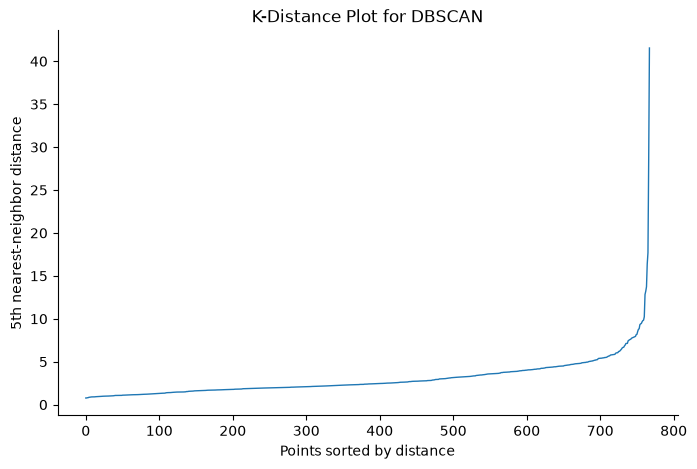

In [228]:
neighbors = NearestNeighbors(n_neighbors=5)  # Use the 5th nearest neighbor
distances, _ = neighbors.fit(X_pca).kneighbors(X_pca)  # Compute neighbor distances

k_distances = np.sort(distances[:, -1])  # Sort the 5th-neighbor distances

plt.figure(figsize=(8, 5))  # Create the plot
plt.plot(k_distances)  # Plot sorted k-distances
plt.xlabel("Points sorted by distance")  # Label x-axis
plt.ylabel("5th nearest-neighbor distance")  # Label y-axis
plt.title("K-Distance Plot for DBSCAN")  # Add plot title
plt.grid()  # Show grid
plt.show()  # Display the plot

In [229]:
for eps in [1, 1.5, 2, 2.5, 3, 3.5, 4]:  # Test several eps values
    dbscan = DBSCAN(eps=eps, min_samples=5)  # Create DBSCAN with the current eps
    labels = dbscan.fit_predict(X_pca)  # Cluster the PCA-transformed data

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)  # Count clusters excluding noise
    n_noise = np.sum(labels == -1)  # Count noise points

    print(f"eps={eps}: clusters={n_clusters}, noise={n_noise}")  # Display the result

eps=1: clusters=2, noise=709
eps=1.5: clusters=4, noise=598
eps=2: clusters=7, noise=420
eps=2.5: clusters=3, noise=298
eps=3: clusters=5, noise=229
eps=3.5: clusters=5, noise=169
eps=4: clusters=3, noise=116


In [230]:
result = metadata.copy()  # Copy metadata for cluster analysis
result["cluster"] = clusters  # Add DBSCAN cluster assignments

print(pd.crosstab(result["cluster"], result["label"]))  # Compare clusters with Bumpy/Smooth labels

label    bumpy  smooth
cluster               
-1          86      30
 0         303     314
 1           0      29
 2           6       0


Visualization των DBSCAN clusters

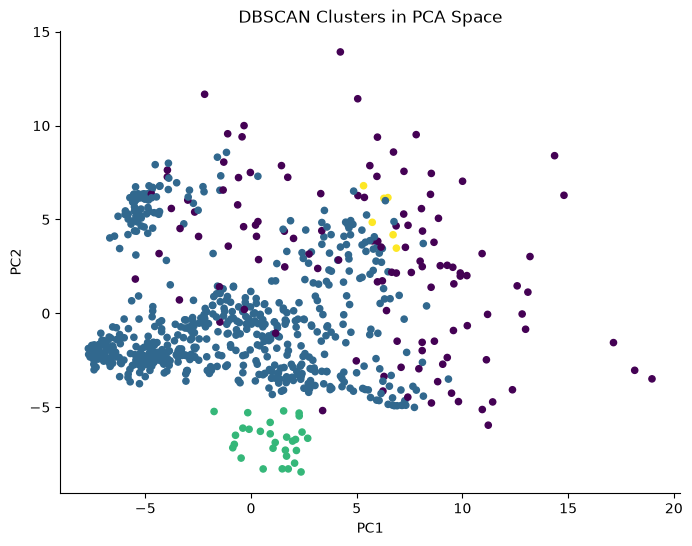

In [231]:
plt.figure(figsize=(8, 6))  # Create the plot

plt.scatter(
    X_pca[:, 0],  # First principal component
    X_pca[:, 1],  # Second principal component
    c=clusters,   # Color points according to their DBSCAN cluster
    s=20          # Set marker size
)

plt.xlabel("PC1")  # Label x-axis
plt.ylabel("PC2")  # Label y-axis
plt.title("DBSCAN Clusters in PCA Space")  # Add plot title
plt.grid()  # Show grid
plt.show()  # Display the plot

t-SNE

In [232]:
tsne = TSNE(
    n_components=2,  # Reduce the data to two dimensions
    random_state=42,  # Make the result reproducible
    perplexity=30  # Set the balance between local and global structure
)

X_tsne = tsne.fit_transform(X_pca)  # Compute the 2D t-SNE representation

print(X_tsne.shape)  # Check the resulting shape

(768, 2)


t-SNE visualization

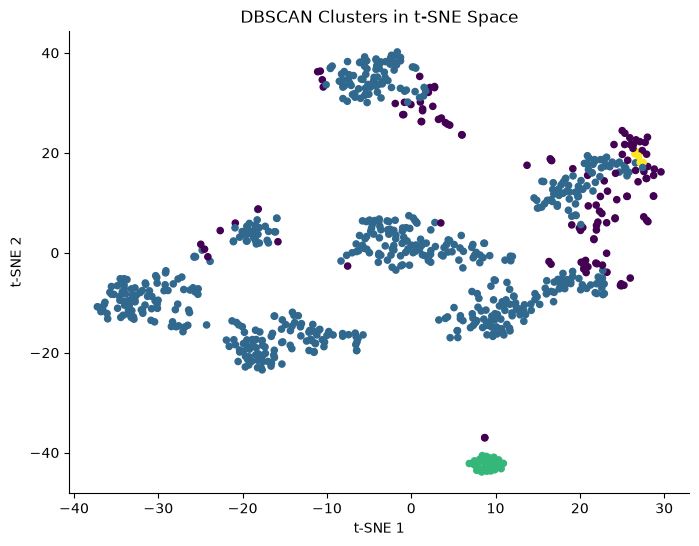

In [233]:
plt.figure(figsize=(8, 6))  # Create the plot

plt.scatter(
    X_tsne[:, 0],  # First t-SNE dimension
    X_tsne[:, 1],  # Second t-SNE dimension
    c=clusters,  # Color points according to DBSCAN cluster
    s=20  # Set marker size
)

plt.xlabel("t-SNE 1")  # Label x-axis
plt.ylabel("t-SNE 2")  # Label y-axis
plt.title("DBSCAN Clusters in t-SNE Space")  # Add plot title
plt.grid()  # Show grid
plt.show()  # Display the plot

Cluster Label Distribution

In [234]:
cluster_table = pd.crosstab(
    result["cluster"],  # DBSCAN cluster
    result["label"],
    normalize="index"  # Convert counts to percentages within each cluster
) * 100

print(cluster_table.round(1))  # Display percentages for each cluster

label    bumpy  smooth
cluster               
-1        74.1    25.9
 0        49.1    50.9
 1         0.0   100.0
 2       100.0     0.0


t-SNE Visualization by Surface Label

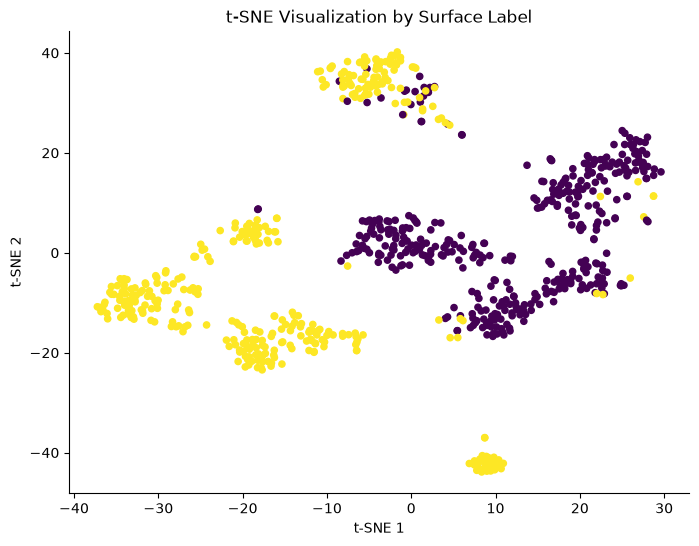

In [235]:
plt.figure(figsize=(8, 6))  # Create the plot

colors = metadata["label"].map({"bumpy": 0, "smooth": 1})  # Convert labels to numeric values

plt.scatter(
    X_tsne[:, 0],  # First t-SNE dimension
    X_tsne[:, 1],  # Second t-SNE dimension
    c=colors,  # Color points according to surface label
    s=20  # Set marker size
)

plt.xlabel("t-SNE 1")  # Label x-axis
plt.ylabel("t-SNE 2")  # Label y-axis
plt.title("t-SNE Visualization by Surface Label")  # Add plot title
plt.grid()  # Show grid
plt.show()  # Display the plot

DBSCAN min_samples Sensitivity

In [236]:
for min_samples in [3, 5, 10, 15]:  # Test different minimum neighborhood sizes
    dbscan = DBSCAN(eps=4, min_samples=min_samples)  # Keep eps fixed at 4
    labels = dbscan.fit_predict(X_pca)  # Run DBSCAN

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)  # Count clusters excluding noise
    n_noise = np.sum(labels == -1)  # Count noise points

    print(
        f"min_samples={min_samples}: clusters={n_clusters}, noise={n_noise}"
    )  # Display the result

min_samples=3: clusters=4, noise=100
min_samples=5: clusters=3, noise=116
min_samples=10: clusters=2, noise=144
min_samples=15: clusters=4, noise=192


## 6.1 Evaluation: DBSCAN conversion to classifier

The clustering above (`clusters`, eps = 4, min_samples = 5) never used a label. To compare it with the other models, the same splits as in 5.7 only decide how each cluster is **named**:

1. name each cluster, and the noise points (-1), after the majority label of the **training** windows in it
2. every test window gets the name of its cluster

Note: the clustering itself was fitted on all windows (labels not used), so this is slightly more optimistic than refitting per split.


In [ ]:
assert (df["window_id"].to_numpy() == metadata["window_id"].to_numpy()).all()   # same windows, same order

def dbscan_predict(tr, te):
    # 1. Cast to numpy arrays to guarantee safe positional indexing 
    y_tr = np.asarray(y)[tr]
    clusters_tr = np.asarray(clusters)[tr]
    clusters_te = np.asarray(clusters)[te]
    
    # 2. Calculate the global training majority (fallback for noise and unseen clusters)
    train_majority = y_tr.mean() > 0.5
    
    # 3. Find majority label per cluster, strictly IGNORING noise (-1)
    valid_mask = clusters_tr != -1
    cluster_labels = (
        pd.Series(y_tr[valid_mask])
        .groupby(clusters_tr[valid_mask])
        .mean() > 0.5
    )
    
    # 4. Map test clusters to labels. 
    # Because -1 wasn't in cluster_labels, it will become NaN and hit the fillna()
    yhat = pd.Series(clusters_te).map(cluster_labels).fillna(train_majority).astype(int).to_numpy()
    
    return yhat

DBSCAN_NAME = "DBSCAN, PCA 95% (eps=4, min_samples=5)"
metric_rows, pred_frames = [], []
for split_name, splits in SPLITS.items():
    for fold_name, (tr, te) in zip(FOLD_NAMES[split_name], splits):
        yhat = dbscan_predict(tr, te)
        metric_rows.append({"split": split_name, "model": DBSCAN_NAME, "held_out": fold_name,
                            **classification_metrics(y[te], yhat)})
        
        pred_frames.append(
            df.loc[te, ["recording_id", "participant", "label"]]
            .assign(
                split=split_name, 
                model=DBSCAN_NAME, 
                held_out=fold_name,
                pred=np.where(yhat == 1, "bumpy", "smooth")
            )
        )

per_fold = pd.DataFrame(metric_rows)
summary = per_fold.groupby(["split", "model"])[METRICS].agg(["mean", "min"])
summary.columns = [f"{m}_{stat}" for m, stat in summary.columns]

per_fold.to_csv(RESULTS_DIR / "dbscan_metrics_per_fold.csv", index=False)
summary.to_csv(RESULTS_DIR / "dbscan_metrics_summary.csv")
pd.concat(pred_frames).rename_axis("window").to_csv(RESULTS_DIR / "dbscan_predictions.csv")
print(f"saved to {RESULTS_DIR.resolve()}")

summary[[f"{m}_mean" for m in METRICS]].round(3)

saved to D:\2-Courses\5ARE0-Project\Machine_Learning_for_rides\artifacts\results


,,accuracy_mean,balanced_accuracy_mean,precision_mean,recall_mean,specificity_mean,f1_mean
split,model,,,,,,
grouped folds,"DBSCAN, PCA 95% (eps=4, min_samples=5)",0.414,0.500,0.428,0.500,0.500,0.599
leave-one-participant-out,"DBSCAN, PCA 95% (eps=4, min_samples=5)",0.427,0.425,0.378,0.233,0.618,0.348
